# Selective Prediction 
**Goal:** Demonstrate that C_k based metrics enables safe selective prediction by detecting epistemic confusion **specifically across the safe/critical boundary**.

**Key innovation:** High C_k on a critical class could arise from:
- Safe-safe confusion (Grade 0↔1) — acceptable, no deferral needed
- Critical-critical confusion (Grade 2↔3) — acceptable, no deferral needed  
- **Boundary confusion (Grade 0↔3, 2 or 1-2, 3 vice versa ..)** — dangerous, must defer

CBEC isolates boundary confusion by combining per-class C_k with pairwise negative correlation:
$$\text{CBEC}(x) = \sum_{i \in \text{safe}} \sum_{j \in \text{critical}} \sqrt{C_i \cdot C_j} \cdot \max(0, -\rho_{ij})$$

**Deferral policies compared:**
- Scalar baselines: Entropy, MI, MaxProb
- Per-class baselines: Var_critical, Sale EU (global & critical), One-vs-All MI
**PROPOSED:** Dynamic based on CRITICAL_CLASSES
  - Single critical class (e.g., [3]): **CBEC** (Cross-Boundary Epistemic Confusion)
  - Multiple critical classes (e.g., [2,3]): **C_critical_max** and **C_critical_sum**


In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import gc
import random
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report, confusion_matrix, cohen_kappa_score
)
from scipy import stats as scipy_stats

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f'Enabled memory growth for {len(gpus)} GPU(s)')

SEED = 42
def set_seed(seed=SEED):
    os.environ['PYTHONHASHSEED'] = str(seed)
    tf.keras.backend.clear_session()
    gc.collect()
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    tf.keras.utils.set_random_seed(seed)

print(f'TensorFlow: {tf.__version__}')
print(f'GPUs: {tf.config.list_physical_devices("GPU")}')

2026-02-22 13:01:31.234311: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-02-22 13:01:31.234343: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-02-22 13:01:31.235443: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Enabled memory growth for 1 GPU(s)
TensorFlow: 2.15.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Configuration & Data Loading

## 2. Rebuild Bayesian Model & Load Weights

## 3. Monte Carlo Inference & Compute All Uncertainties

In [6]:
import numpy as np
from sklearn.metrics import roc_auc_score

# 1) Load Bayesian saved outputs
mc_predictions = np.load("results_bayesian/mc_predictions.npy")
y_true = np.load("results_bayesian/y_true.npy")

print("mc_predictions shape:", mc_predictions.shape)
print("y_true shape:", y_true.shape)

# 2) Convert to class probabilities [N, K]
# If MC samples are saved: [S, N, K] -> average over S
# If already [N, K], keep as-is
mu = mc_predictions.mean(axis=0) if mc_predictions.ndim == 3 else mc_predictions

# 3) Convert y_true to class ids if needed (one-hot -> ids)
if y_true.ndim > 1:
    y_true = np.argmax(y_true, axis=1)

# 4) Multiclass AUROC
auroc_macro_ovr = roc_auc_score(y_true, mu, multi_class="ovr", average="macro")
print(f"Bayesian AUROC (multiclass, macro OVR): {auroc_macro_ovr:.4f}")

# 5) Optional: critical-vs-safe AUROC
CRITICAL_CLASSES = [2, 3]
y_bin = np.isin(y_true, CRITICAL_CLASSES).astype(int)
p_critical = mu[:, CRITICAL_CLASSES].sum(axis=1)
auroc_critical = roc_auc_score(y_bin, p_critical)
print(f"Bayesian AUROC (critical vs safe): {auroc_critical:.4f}")


mc_predictions shape: (30, 7948, 4)
y_true shape: (7948,)
Bayesian AUROC (multiclass, macro OVR): 0.7820
Bayesian AUROC (critical vs safe): 0.8695


In [7]:
metrics = compute_all_uncertainties(mc_predictions, critical_classes=CRITICAL_CLASSES)

y_pred = metrics['y_pred']
N_test = len(y_true)

print('All uncertainty metrics computed.')
for key, val in metrics.items():
    if isinstance(val, np.ndarray):
        print(f'  {key:<20s} {str(val.shape):<15s} [{val.min():.4f}, {val.max():.4f}]')

All uncertainty metrics computed.
  mu                   (7948, 4)       [0.0000, 1.0000]
  var                  (7948, 4)       [0.0000, 0.0838]
  m3                   (7948, 4)       [-0.0171, 0.0160]
  C_k                  (7948, 4)       [0.0000, 0.1683]
  rho_k                (7948, 4)       [0.0000, 9.3304]
  C_critical_sum       (7948,)         [0.0000, 0.1783]
  C_critical_max       (7948,)         [0.0000, 0.1373]
  sum_C_k              (7948,)         [0.0000, 0.3469]
  entropy              (7948,)         [0.0002, 1.2403]
  MI                   (7948,)         [0.0000, 0.3164]
  maxprob              (7948,)         [0.0000, 0.6076]
  var_critical_max     (7948,)         [0.0000, 0.0838]
  sale_eu              (7948, 4)       [0.0000, 0.0838]
  sale_eu_global       (7948,)         [0.0000, 0.1580]
  sale_eu_critical     (7948,)         [0.0000, 0.1575]
  ova_mi_per_class     (7948, 2)       [0.0000, 0.2133]
  ova_mi_sum           (7948,)         [0.0000, 0.4043]
  corr       

In [8]:
# Sanity check: Bayesian model performance
test_acc = np.mean(y_pred == y_true)
qwk = cohen_kappa_score(y_true, y_pred, weights='quadratic')

print(f'Bayesian Test Accuracy (MC avg, S={N_MC_SAMPLES}): {test_acc:.4f}')
print(f'Quadratic Weighted Kappa: {qwk:.4f}')
print()
print(classification_report(
    y_true, y_pred,
    target_names=['Grade 0', 'Grade 1', 'Grade 2', 'Grade 3'],
    zero_division=0
))
print('Confusion Matrix:')
print(confusion_matrix(y_true, y_pred))

Bayesian Test Accuracy (MC avg, S=30): 0.7939
Quadratic Weighted Kappa: 0.6460

              precision    recall  f1-score   support

     Grade 0       0.83      0.98      0.89      5584
     Grade 1       0.00      0.00      0.00       587
     Grade 2       0.62      0.56      0.59      1322
     Grade 3       0.75      0.28      0.41       455

    accuracy                           0.79      7948
   macro avg       0.55      0.45      0.47      7948
weighted avg       0.73      0.79      0.75      7948

Confusion Matrix:
[[5447    0  134    3]
 [ 497    0   89    1]
 [ 548    0  735   39]
 [ 107    0  220  128]]


## 4. Theory Validation: MI $\approx$ $\sum_k C_k$

From the 2nd-order Taylor expansion: the sum of per-class epistemic uncertainties should approximate mutual information.

Theory validation: MI vs Sum(C_k)
  Pearson  r = 0.9884  (p = 0.00e+00)
  Spearman r = 0.9979  (p = 0.00e+00)
  Result: PASS


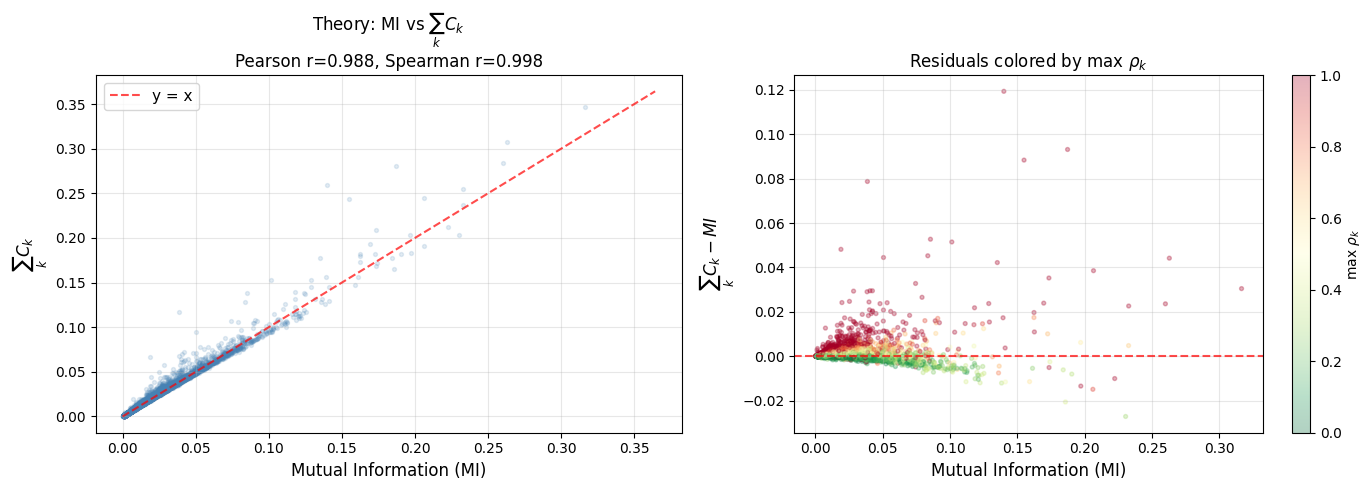

In [9]:
MI = metrics['MI']
corr = metrics['corr']
sum_C_k = metrics['sum_C_k']
rho_k = metrics['rho_k']

r_pearson, p_pearson = scipy_stats.pearsonr(MI, sum_C_k)
r_spearman, p_spearman = scipy_stats.spearmanr(MI, sum_C_k)

print(f'Theory validation: MI vs Sum(C_k)')
print(f'  Pearson  r = {r_pearson:.4f}  (p = {p_pearson:.2e})')
print(f'  Spearman r = {r_spearman:.4f}  (p = {p_spearman:.2e})')
print(f'  Result: {"PASS" if r_pearson > 0.9 else "CHECK — see skewness diagnostics"}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MI vs Sum(C_k)
ax = axes[0]
ax.scatter(MI, sum_C_k, alpha=0.15, s=8, c='steelblue')
lim = max(MI.max(), sum_C_k.max()) * 1.05
ax.plot([0, lim], [0, lim], 'r--', alpha=0.7, label='y = x')
ax.set_xlabel('Mutual Information (MI)', fontsize=12)
ax.set_ylabel(r'$\sum_k C_k$', fontsize=12)
ax.set_title(f'Theory: MI vs $\\sum_k C_k$\n'
             f'Pearson r={r_pearson:.3f}, Spearman r={r_spearman:.3f}', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Residuals colored by max rho_k
ax = axes[1]
residual = sum_C_k - MI
max_rho = np.max(rho_k, axis=1)
sc = ax.scatter(MI, residual, c=max_rho, cmap='RdYlGn_r', alpha=0.3, s=8,
                vmin=0, vmax=1.0)
ax.axhline(0, color='r', linestyle='--', alpha=0.7)
ax.set_xlabel('Mutual Information (MI)', fontsize=12)
ax.set_ylabel(r'$\sum_k C_k - MI$', fontsize=12)
ax.set_title(r'Residuals colored by max $\rho_k$', fontsize=12)
plt.colorbar(sc, ax=ax, label=r'max $\rho_k$')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/selective_prediction_theory_validation.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Skewness Diagnostic Analysis

$\rho_k \ll 1$: $C_k$ reliable. $\rho_k > 0.3$: interpret with caution.

Skewness Diagnostic (rho_k) Summary

Grade 0:
  Valid (Var>0): 7865 / 7948
  rho_k: median=0.0121, mean=0.0863, p90=0.1161
  C_k reliable (rho<0.3): 94.6%

Grade 1:
  Valid (Var>0): 7929 / 7948
  rho_k: median=0.0366, mean=0.0820, p90=0.1351
  C_k reliable (rho<0.3): 97.0%

Grade 2:
  Valid (Var>0): 7946 / 7948
  rho_k: median=0.1239, mean=0.1982, p90=0.4228
  C_k reliable (rho<0.3): 81.6%

Grade 3:
  Valid (Var>0): 7938 / 7948
  rho_k: median=0.2182, mean=0.3280, p90=0.7059
  C_k reliable (rho<0.3): 63.4%

Overall: 57.0% of samples have ALL rho_k < 0.3


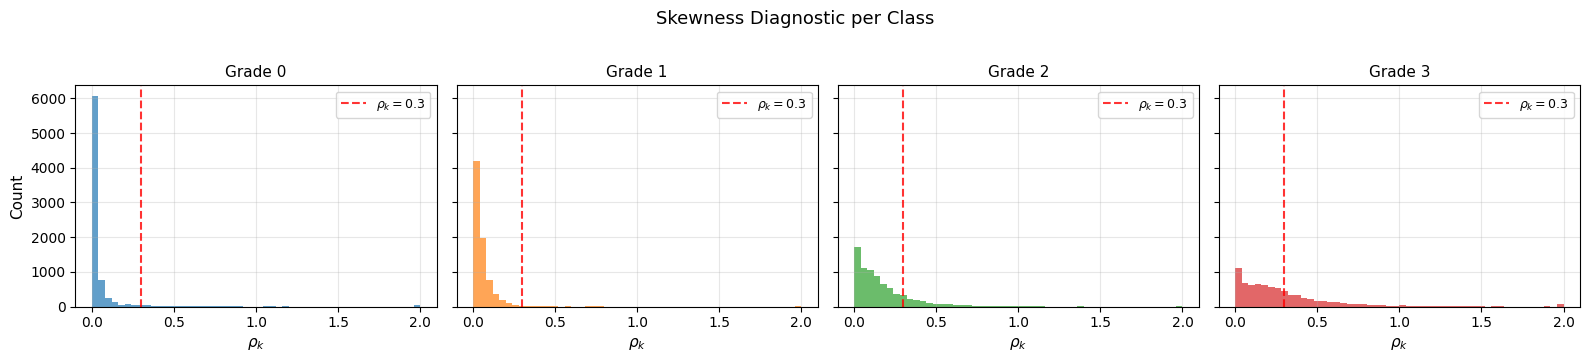

In [10]:
var = metrics['var']

print('Skewness Diagnostic (rho_k) Summary')
print('=' * 60)

for k in range(4):
    rk = rho_k[:, k]
    valid = var[:, k] > 1e-12
    rk_valid = rk[valid]
    reliable = np.mean(rk_valid < 0.3) * 100 if len(rk_valid) > 0 else 0

    print(f'\nGrade {k}:')
    print(f'  Valid (Var>0): {valid.sum()} / {N_test}')
    if len(rk_valid) > 0:
        print(f'  rho_k: median={np.median(rk_valid):.4f}, '
              f'mean={np.mean(rk_valid):.4f}, '
              f'p90={np.percentile(rk_valid, 90):.4f}')
        print(f'  C_k reliable (rho<0.3): {reliable:.1f}%')

max_rho_all = np.max(rho_k, axis=1)
reliable_overall = np.mean(max_rho_all < 0.3) * 100
print(f'\nOverall: {reliable_overall:.1f}% of samples have ALL rho_k < 0.3')

# Distribution plots
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5), sharey=True)
for k in range(4):
    ax = axes[k]
    valid = var[:, k] > 1e-12
    rk_valid = rho_k[valid, k]
    if len(rk_valid) > 0:
        ax.hist(np.clip(rk_valid, 0, 2), bins=50, alpha=0.7, color=f'C{k}')
    ax.axvline(0.3, color='red', linestyle='--', alpha=0.8, label=r'$\rho_k=0.3$')
    ax.set_title(f'Grade {k}', fontsize=11)
    ax.set_xlabel(r'$\rho_k$', fontsize=11)
    if k == 0:
        ax.set_ylabel('Count', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Skewness Diagnostic per Class', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('figures/selective_prediction_skewness.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Selective Prediction: All Policies

| Group | Policy | Score |
|-------|--------|-------|
| Scalar baseline | Entropy | $H[\mu]$ |
| Scalar baseline | MI | $H[\mu] - \mathbb{E}_s[H[p^{(s)}]]$ |
| Scalar baseline | MaxProb | $1 - \max_k \mu_k$ |
| Per-class baseline | Var_critical | $\max_{k\in\mathcal{critical}} \text{Var}[p_k]$ |
| Per-class baseline | Sale_EU_global | $\sum_k \text{Var}[p_k]$ |
| Per-class baseline | Sale_EU_critical | $\sum_{k\in\mathcal{critical}} \text{Var}[p_k]$ |
| Per-class baseline | OvA_MI | $\sum_{k\in critical} \text{MI}_k^{\text{binary}}$ |
| Ablation / PROPOSED* | C_critical_sum | $\sum_{k\in critical} C_k$ — diagonal only |
| Ablation / PROPOSED* | C_critical_max | $\max_{k\in critical} C_k$ — diagonal only |
| Ablation | Boundary_MI | $H(\mu_{\text{crit}}) - \mathbb{E}_s[H(p_{\text{crit}}^{(s)})]$ — coarsened binary |
| Ablation / PROPOSED* | CBEC | $\sum_{i \in S, j \in C} \sqrt{C_i \cdot C_j} \cdot \max(0, -\rho_{ij})$ — structure-aware |

*PROPOSED label is assigned dynamically:
- Single critical class (e.g., [3]): CBEC is PROPOSED
- Multiple critical classes (e.g., [2,3]): C_critical_max and C_critical_sum are PROPOSED


In [11]:
import importlib
import modules.uncertaintybis
importlib.reload(modules.uncertaintybis)
from modules.uncertaintybis import (
    build_deferral_policies, selective_prediction_eval, compute_ausc
)

policies = build_deferral_policies(metrics)

all_results = {}
for name, scores in policies.items():
    all_results[name] = selective_prediction_eval(
        y_true, y_pred, scores, COVERAGE_LEVELS,
        critical_classes=CRITICAL_CLASSES
    )

print(f'Evaluated {len(policies)} deferral policies at {len(COVERAGE_LEVELS)} coverage levels.')

Evaluated 10 deferral policies at 7 coverage levels.


## 7. Results Table at 80% Coverage

In [12]:
target_cov = 0.80

print(f'Selective Prediction at {target_cov*100:.0f}% Coverage')
print('=' * 100)
print(f'{"Group":<22} {"Policy":<20} {"Accuracy":>10} {"Macro F1":>10} '
      f'{"Crit FNR":>10} {"Crit N":>8} {"Crit Defer%":>12}')
print('-' * 100)

# Dynamically assign PROPOSED label based on CRITICAL_CLASSES
group_map = {
    'Entropy': 'Scalar',   'MI': 'Scalar',   'MaxProb': 'Scalar',
    'Var_critical': 'Per-class', 'Sale_EU_global': 'Per-class',
    'Sale_EU_critical': 'Per-class', 'OvA_MI': 'Per-class',
}
# Assign PROPOSED and Ablation labels dynamically
if is_single_critical:
    group_map['CBEC'] = 'PROPOSED'
    group_map['C_critical_sum'] = 'Ablation'
    group_map['C_critical_max'] = 'Ablation'
else:
    group_map['CBEC'] = 'Ablation'
    group_map['C_critical_sum'] = 'PROPOSED'
    group_map['C_critical_max'] = 'PROPOSED'

for name in policies:
    for r in all_results[name]:
        if r['coverage'] == target_cov:
            g = group_map[name]
            print(f'{g:<22} {name:<20} {r["accuracy"]:>10.4f} {r["f1_macro"]:>10.4f} '
                  f'{r["critical_fnr"]:>10.4f} {r["critical_n"]:>8d} '
                  f'{r["critical_defer_rate"]:>11.1%}')

print('-' * 100)
print(f'Critical classes: {CRITICAL_CLASSES} (Grade 3 = Severe + PDR)')
print(f'Critical FNR = fraction of critical cases (in auto-decided set) misclassified')
print(f'Critical Defer% = fraction of ALL critical cases deferred to human')

Selective Prediction at 80% Coverage
Group                  Policy                 Accuracy   Macro F1   Crit FNR   Crit N  Crit Defer%
----------------------------------------------------------------------------------------------------
Scalar                 Entropy                  0.8418     0.4911     0.3994     1029       42.1%
Scalar                 MI                       0.8374     0.4953     0.3390     1183       33.4%
Scalar                 MaxProb                  0.8457     0.4946     0.4383      965       45.7%
Per-class              Var_critical             0.8409     0.4674     0.3811     1068       39.9%
Per-class              Sale_EU_global           0.8399     0.4855     0.3406     1145       35.6%
Per-class              Sale_EU_critical         0.8426     0.4561     0.4092     1019       42.7%
Per-class              OvA_MI                   0.8376     0.4543     0.3662     1114       37.3%
PROPOSED               C_critical_sum           0.8302     0.4696     0.3207 

In [13]:
# Full results across all coverage levels
print('Full Results: All Policies x All Coverage Levels')
print('=' * 110)

for name in policies:
    g = group_map[name]
    print(f'\n--- [{g}] {name} ---')
    print(f'{"Coverage":>10} {"Kept":>8} {"Accuracy":>10} {"Macro F1":>10} '
          f'{"Crit FNR":>10} {"Crit N":>8} {"Crit Defer%":>12}')
    for r in all_results[name]:
        print(f'{r["coverage"]:>9.0%} {r["n_kept"]:>8d} {r["accuracy"]:>10.4f} '
              f'{r["f1_macro"]:>10.4f} {r["critical_fnr"]:>10.4f} '
              f'{r["critical_n"]:>8d} {r["critical_defer_rate"]:>11.1%}')

Full Results: All Policies x All Coverage Levels

--- [Scalar] Entropy ---
  Coverage     Kept   Accuracy   Macro F1   Crit FNR   Crit N  Crit Defer%
      50%     3974     0.8775     0.4025     0.7867      286       83.9%
      60%     4769     0.8733     0.4098     0.7580      376       78.8%
      70%     5564     0.8609     0.4439     0.6181      576       67.6%
      80%     6359     0.8418     0.4911     0.3994     1029       42.1%
      90%     7154     0.8239     0.4875     0.3802     1373       22.7%
      95%     7551     0.8101     0.4808     0.3832     1571       11.6%
     100%     7948     0.7939     0.4728     0.3686     1777        0.0%

--- [Scalar] MI ---
  Coverage     Kept   Accuracy   Macro F1   Crit FNR   Crit N  Crit Defer%
      50%     3974     0.8639     0.4831     0.3565      575       67.6%
      60%     4769     0.8580     0.4864     0.3243      771       56.6%
      70%     5564     0.8485     0.4906     0.3319      961       45.9%
      80%     6359     0

## 8. Coverage vs Critical FNR Curves

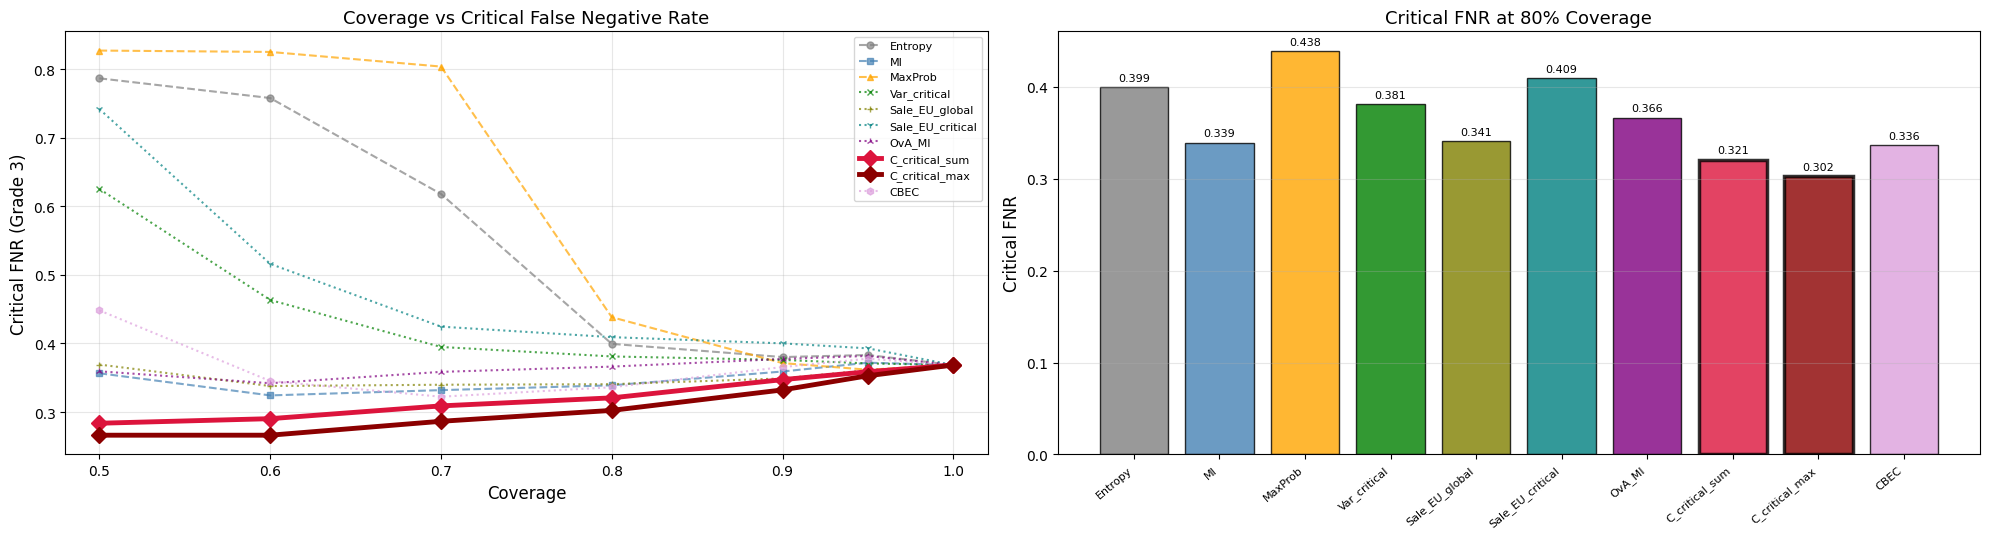

In [14]:
# Dynamic styling: PROPOSED metrics get bold crimson style
style_map = {
    # Scalar baselines
    'Entropy':          {'color': 'gray',        'ls': '--', 'marker': 'o'},
    'MI':               {'color': 'steelblue',   'ls': '--', 'marker': 's'},
    'MaxProb':          {'color': 'orange',      'ls': '--', 'marker': '^'},
    # Per-class baselines
    'Var_critical':     {'color': 'green',       'ls': ':',  'marker': 'x'},
    'Sale_EU_global':   {'color': 'olive',       'ls': ':',  'marker': '+'},
    'Sale_EU_critical': {'color': 'teal',        'ls': ':',  'marker': '1'},
    'OvA_MI':           {'color': 'purple',      'ls': ':',  'marker': '2'},
}

# Dynamically assign styles for PROPOSED metrics (bold) and ablations (light)
if is_single_critical:
    style_map['CBEC'] = {'color': 'crimson', 'ls': '-', 'marker': 'D'}  # PROPOSED
    style_map['C_critical_sum'] = {'color': 'lightcoral', 'ls': ':', 'marker': 'd'}  # Ablation
    style_map['C_critical_max'] = {'color': 'salmon', 'ls': ':', 'marker': 'v'}  # Ablation
else:
    style_map['CBEC'] = {'color': 'plum', 'ls': ':', 'marker': 'h'}  # Ablation
    style_map['C_critical_sum'] = {'color': 'crimson', 'ls': '-', 'marker': 'D'}  # PROPOSED
    style_map['C_critical_max'] = {'color': 'darkred', 'ls': '-', 'marker': 'D'}  # PROPOSED

fig, axes = plt.subplots(1, 2, figsize=(20, 5.5))

# --- Plot 1: Coverage vs Critical FNR ---
ax = axes[0]
for name in policies:
    covs = [r['coverage'] for r in all_results[name]]
    fnrs = [r['critical_fnr'] for r in all_results[name]]
    s = style_map[name]
    # Make CBEC thick and prominent
    lw = 3.5 if name in PROPOSED_METRICS else 1.5
    ms = 8 if name in PROPOSED_METRICS else 5
    alpha = 1.0 if name in PROPOSED_METRICS else 0.7
    zorder = 10 if name in PROPOSED_METRICS else 5
    ax.plot(covs, fnrs, color=s['color'], linestyle=s['ls'], marker=s['marker'],
            linewidth=lw, markersize=ms, label=name, alpha=alpha, zorder=zorder)
ax.set_xlabel('Coverage', fontsize=12)
ax.set_ylabel('Critical FNR (Grade 3)', fontsize=12)
ax.set_title('Coverage vs Critical False Negative Rate', fontsize=13)
ax.legend(fontsize=8, loc='best')
ax.grid(True, alpha=0.3)
ax.set_xlim(0.48, 1.02)
"""
# --- Plot 2: Coverage vs Accuracy ---
ax = axes[1]
for name in policies:
    covs = [r['coverage'] for r in all_results[name]]
    accs = [r['accuracy'] for r in all_results[name]]
    s = style_map[name]
    lw = 3.5 if name in PROPOSED_METRICS else 1.5
    ms = 8 if name in PROPOSED_METRICS else 5
    alpha = 1.0 if name in PROPOSED_METRICS else 0.7
    zorder = 10 if name in PROPOSED_METRICS else 5
    ax.plot(covs, accs, color=s['color'], linestyle=s['ls'], marker=s['marker'],
            linewidth=lw, markersize=ms, label=name, alpha=alpha, zorder=zorder)
ax.set_xlabel('Coverage', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Coverage vs Accuracy', fontsize=13)
ax.legend(fontsize=8, loc='best')
ax.grid(True, alpha=0.3)
ax.set_xlim(0.48, 1.02)
"""
# --- Plot 3: Bar chart at 80% coverage ---
ax = axes[1]
bar_names = []
bar_fnrs = []
bar_colors = []
bar_alphas = []
for name in policies:
    for r in all_results[name]:
        if r['coverage'] == 0.80:
            bar_names.append(name)
            bar_fnrs.append(r['critical_fnr'])
            bar_colors.append(style_map[name]['color'])
            bar_alphas.append(1.0 if name == 'CBEC' else 0.7)

bars = ax.bar(range(len(bar_names)), bar_fnrs, color=bar_colors, alpha=0.8, edgecolor='black')
# Highlight CBEC bar
for i, (bar, name) in enumerate(zip(bars, bar_names)):
    if name in PROPOSED_METRICS:
        bar.set_edgecolor('black')
        bar.set_linewidth(2.5)
ax.set_xticks(range(len(bar_names)))
ax.set_xticklabels(bar_names, rotation=40, ha='right', fontsize=8)
ax.set_ylabel('Critical FNR', fontsize=12)
ax.set_title('Critical FNR at 80% Coverage', fontsize=13)
ax.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, bar_fnrs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('figures/selective_prediction_coverage_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. AUSC (Area Under Selective Risk Curve)

In [15]:
print('Area Under Selective Risk Curve (AUSC) — lower is better')
print('=' * 85)
print(f'{"Group":<18} {"Policy":<20} {"AUSC (Crit FNR)":>18} {"AUSC (Crit Err)":>16} {"AUSC (Error Rate)":>18}')
print('-' * 85)

ausc_data = {}
for name, scores in policies.items():
    ausc_fnr, covs, risks_fnr = compute_ausc(
        y_true, y_pred, scores, CRITICAL_CLASSES, metric='critical_fnr'
    )
    ausc_cerr, _, risks_cerr = compute_ausc(
        y_true, y_pred, scores, CRITICAL_CLASSES, metric='critical_err'
    )
    ausc_err, _, risks_err = compute_ausc(
        y_true, y_pred, scores, CRITICAL_CLASSES, metric='error_rate'
    )
    ausc_data[name] = {
        'fnr': ausc_fnr, 'cerr': ausc_cerr, 'err': ausc_err,
        'covs': covs, 'risks_fnr': risks_fnr, 'risks_cerr': risks_cerr, 'risks_err': risks_err
    }
    g = group_map[name]
    print(f'{g:<18} {name:<20} {ausc_fnr:>18.4f} {ausc_cerr:>16.4f} {ausc_err:>18.4f}')

best_fnr_name  = min(ausc_data, key=lambda x: ausc_data[x]['fnr'])
best_cerr_name = min(ausc_data, key=lambda x: ausc_data[x]['cerr'])
best_err_name  = min(ausc_data, key=lambda x: ausc_data[x]['err'])
print('-' * 85)
print(f'Best for Critical FNR:  {best_fnr_name}  ({ausc_data[best_fnr_name]["fnr"]:.4f})')
print(f'Best for Critical Err:  {best_cerr_name}  ({ausc_data[best_cerr_name]["cerr"]:.4f})')
print(f'Best for Error Rate:    {best_err_name}  ({ausc_data[best_err_name]["err"]:.4f})')

Area Under Selective Risk Curve (AUSC) — lower is better
Group              Policy                  AUSC (Crit FNR)  AUSC (Crit Err)  AUSC (Error Rate)
-------------------------------------------------------------------------------------
Scalar             Entropy                          0.6023           0.6644             0.1275
Scalar             MI                               0.4370           0.5395             0.1335
Scalar             MaxProb                          0.6373           0.6820             0.1263
Per-class          Var_critical                     0.6064           0.6666             0.1291
Per-class          Sale_EU_global                   0.4576           0.5470             0.1317
Per-class          Sale_EU_critical                 0.6505           0.7018             0.1288
Per-class          OvA_MI                           0.4539           0.5416             0.1336
PROPOSED           C_critical_sum                   0.3285           0.4378             0.1395
PR

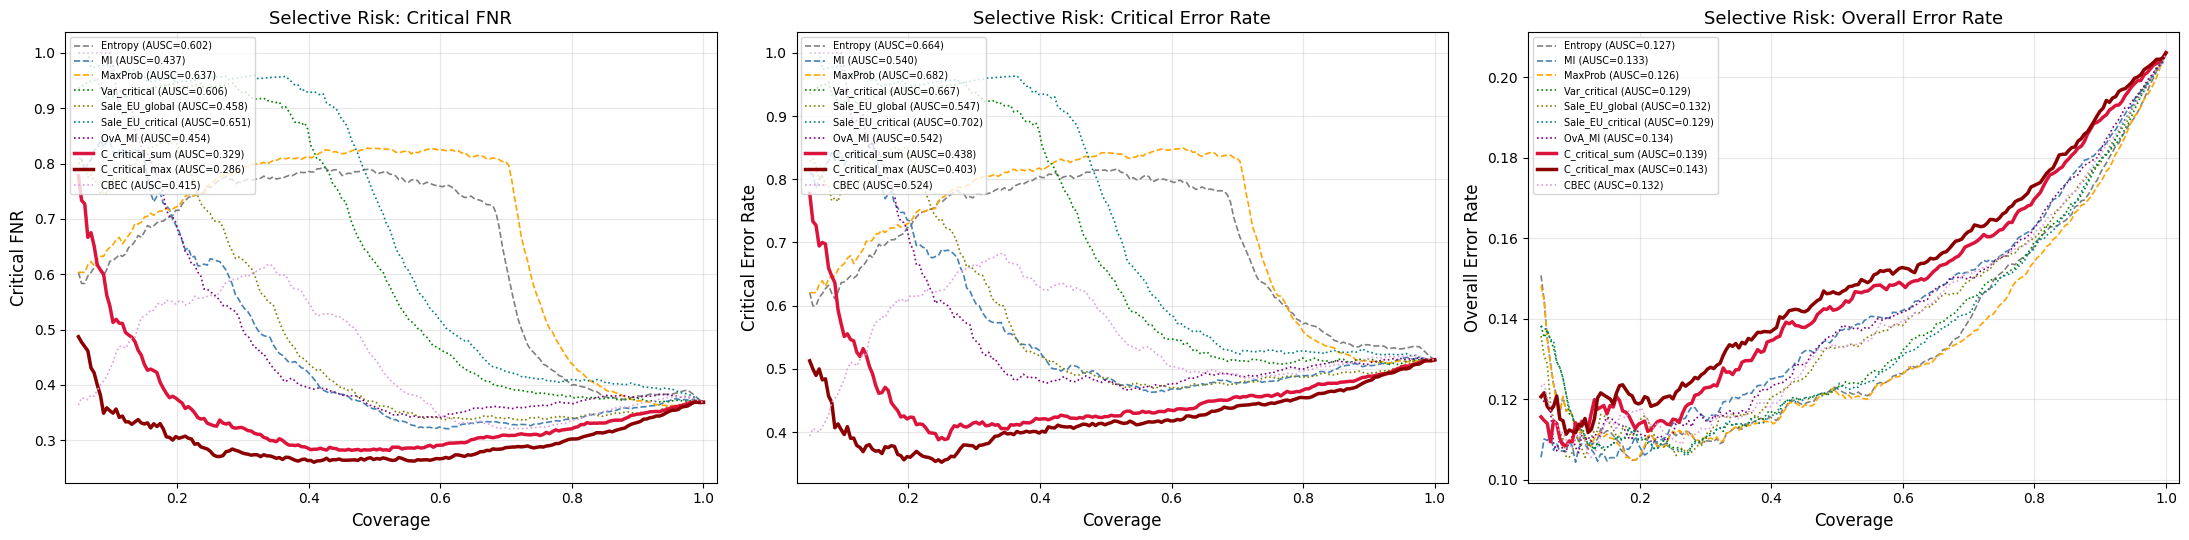

In [16]:
# Smooth AUSC curves
fig, axes = plt.subplots(1, 3, figsize=(22, 5.5))

ausc_key_map = {
    'risks_fnr':  'fnr',
    'risks_cerr': 'cerr',
    'risks_err':  'err',
}

for i, (metric_label, key) in enumerate([('Critical FNR', 'risks_fnr'),
                                          ('Critical Error Rate', 'risks_cerr'),
                                          ('Overall Error Rate', 'risks_err')]):
    ax = axes[i]
    for name in policies:
        s = style_map[name]
        lw = 2.5 if 'C_critical' in name else 1.2
        ausc_val = ausc_data[name][ausc_key_map[key]]
        ax.plot(ausc_data[name]['covs'], ausc_data[name][key],
                color=s['color'], linestyle=s['ls'], linewidth=lw,
                label=f'{name} (AUSC={ausc_val:.3f})')
    ax.set_xlabel('Coverage', fontsize=12)
    ax.set_ylabel(metric_label, fontsize=12)
    ax.set_title(f'Selective Risk: {metric_label}', fontsize=13)
    ax.legend(fontsize=7, loc='upper left')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0.03, 1.02)

plt.tight_layout()
plt.savefig('figures/selective_prediction_ausc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. What Does C_k Catch That Others Miss?

In [17]:
n_keep = int(np.ceil(0.80 * N_test))

# Get deferred sets
deferred_sets = {}
for name, scores in policies.items():
    sorted_idx = np.argsort(scores)
    deferred_sets[name] = set(sorted_idx[n_keep:])

# Critical misclassifications
critical_mask = np.isin(y_true, CRITICAL_CLASSES)
misclassified = y_pred != y_true
critical_errors = np.where(critical_mask & misclassified)[0]

print(f'Total critical errors (Grade 3 misclassified): {len(critical_errors)}')
print(f'At 80% coverage, each policy defers {N_test - n_keep} samples\n')

print(f'{"Group":<18} {"Policy":<20} {"Crit Errors Deferred":>22} {"Fraction":>10}')
print('-' * 75)
for name in policies:
    caught = len(set(critical_errors) & deferred_sets[name])
    frac = caught / len(critical_errors) if len(critical_errors) > 0 else 0
    g = group_map[name]
    print(f'{g:<18} {name:<20} {caught:>12d} / {len(critical_errors):<6d} {frac:>9.1%}')

Total critical errors (Grade 3 misclassified): 914
At 80% coverage, each policy defers 1589 samples

Group              Policy                 Crit Errors Deferred   Fraction
---------------------------------------------------------------------------
Scalar             Entropy                       326 / 914        35.7%
Scalar             MI                            335 / 914        36.7%
Scalar             MaxProb                       374 / 914        40.9%
Per-class          Var_critical                  361 / 914        39.5%
Per-class          Sale_EU_global                356 / 914        38.9%
Per-class          Sale_EU_critical              376 / 914        41.1%
Per-class          OvA_MI                        357 / 914        39.1%
PROPOSED           C_critical_sum                336 / 914        36.8%
PROPOSED           C_critical_max                326 / 914        35.7%
Ablation           CBEC                          327 / 914        35.8%


In [18]:
# Overlap: C_critical_sum vs each baseline
ck_deferred = deferred_sets['C_critical_sum']

print('Deferral Overlap: C_critical_sum vs Each Baseline')
print('=' * 85)
print(f'{"Baseline":<20} {"Both":>8} {"Only C_k":>10} {"Only Base":>10} '
      f'{"CritErr only C_k":>16} {"CritErr only Base":>18}')
print('-' * 85)

for name in policies:
    if name == 'C_critical_sum':
        continue
    base_deferred = deferred_sets[name]
    both = ck_deferred & base_deferred
    only_ck = ck_deferred - base_deferred
    only_base = base_deferred - ck_deferred

    ce_only_ck = len(set(critical_errors) & only_ck)
    ce_only_base = len(set(critical_errors) & only_base)

    print(f'{name:<20} {len(both):>8d} {len(only_ck):>10d} {len(only_base):>10d} '
          f'{ce_only_ck:>16d} {ce_only_base:>18d}')

Deferral Overlap: C_critical_sum vs Each Baseline
Baseline                 Both   Only C_k  Only Base CritErr only C_k  CritErr only Base
-------------------------------------------------------------------------------------
Entropy                   900        689        689              113                103
MI                       1364        225        225               38                 37
MaxProb                   946        643        643               88                126
Var_critical             1236        353        353               42                 67
Sale_EU_global           1324        265        265               32                 52
Sale_EU_critical         1207        382        382               45                 85
OvA_MI                   1383        206        206               23                 44
C_critical_max           1507         82         82               17                  7
CBEC                     1260        329        329               63    

## 11. Per-Class C_k Distributions (Correct vs Wrong)

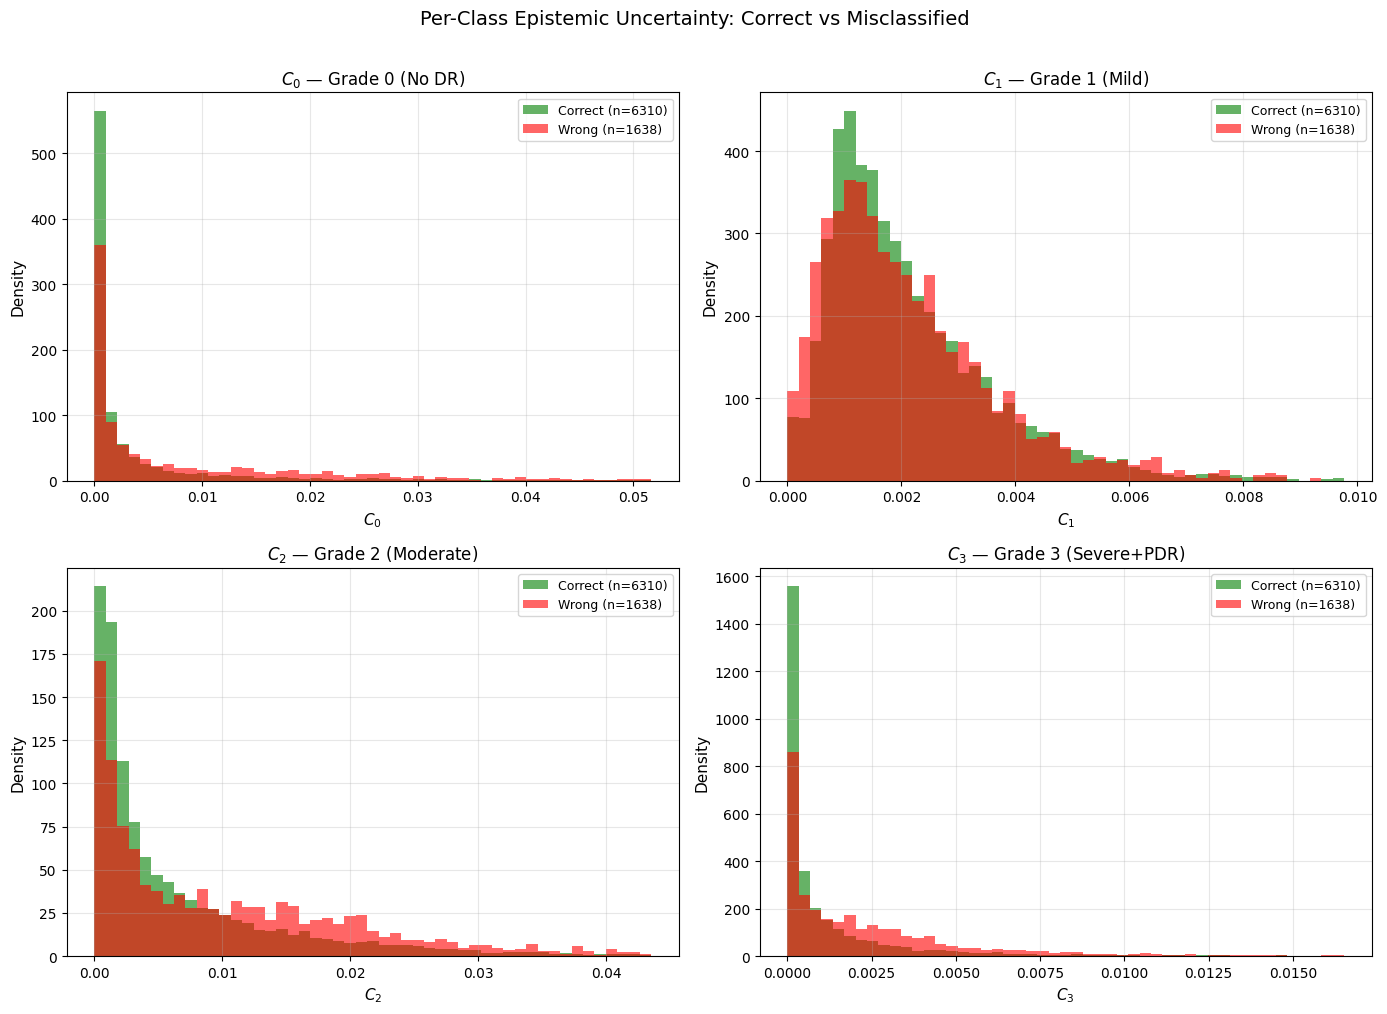

In [19]:
C_k = metrics['C_k']
y_correct = (y_pred == y_true)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for k in range(4):
    ax = axes[k // 2][k % 2]
    ck_correct = C_k[y_correct, k]
    ck_wrong = C_k[~y_correct, k]

    p99 = np.percentile(C_k[:, k], 99)
    bins = np.linspace(0, max(p99, 1e-6), 50)
    ax.hist(ck_correct, bins=bins, alpha=0.6, label=f'Correct (n={len(ck_correct)})',
            color='green', density=True)
    ax.hist(ck_wrong, bins=bins, alpha=0.6, label=f'Wrong (n={len(ck_wrong)})',
            color='red', density=True)
    ax.set_title(f'$C_{{{k}}}$ — {GRADE_NAMES[k]}', fontsize=12)
    ax.set_xlabel(f'$C_{{{k}}}$', fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Per-Class Epistemic Uncertainty: Correct vs Misclassified', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('figures/selective_prediction_ck_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Summary & Success Criteria

In [20]:
print('=' * 80)
print('EXPERIMENT SUMMARY')
print('=' * 80)

print(f'\nModel: Bayesian EfficientNet-B4 (LowRank Variational)')
print(f'MC Samples: {N_MC_SAMPLES}')
print(f'Test set: {N_test} images')
print(f'Overall accuracy: {np.mean(y_pred == y_true):.4f}')
print(f'QWK: {cohen_kappa_score(y_true, y_pred, weights="quadratic"):.4f}')

# Theory validation
r_val, _ = scipy_stats.pearsonr(MI, sum_C_k)
print(f'\nTheory: MI vs Sum(C_k) Pearson r = {r_val:.4f} '
      f'{"PASS" if r_val > 0.9 else "CHECK"}')

# Skewness reliability
max_rho_all = np.max(rho_k, axis=1)
reliable_pct = np.mean(max_rho_all < 0.3) * 100
print(f'Skewness: {reliable_pct:.1f}% of samples have all rho_k < 0.3')

# Best at 80% coverage
best_80_name = None
best_80_fnr = 1.0
for name in policies:
    for r in all_results[name]:
        if r['coverage'] == 0.80 and r['critical_fnr'] < best_80_fnr:
            best_80_fnr = r['critical_fnr']
            best_80_name = name

print(f'\nBest at 80% coverage (lowest Crit FNR): {best_80_name} (FNR={best_80_fnr:.4f})')

# AUSC ranking
print(f'\nAUSC (Critical FNR) ranking:')
sorted_ausc = sorted(ausc_data.items(), key=lambda x: x[1]['fnr'])
for rank, (name, data) in enumerate(sorted_ausc, 1):
    g = group_map[name]
    marker = '★' if name in PROPOSED_METRICS else ' '
    print(f'{marker} {rank}. [{g:<12}] {name:<20}: {data["fnr"]:.4f}')

# Success criteria
print(f'\n{"="*80}')
print('SUCCESS CRITERIA')
print(f'{"="*80}')

c1 = best_80_name in PROPOSED_METRICS
print(f'1. PROPOSED lowest FNR @80%:          {"PASS ✓" if c1 else "FAIL ✗"} (best={best_80_name})')

c2 = r_val > 0.9
print(f'2. MI ~ Sum(C_k) correlation > 0.9:    {"PASS ✓" if c2 else "FAIL ✗"} (r={r_val:.4f})')

# Check if any PROPOSED metric has lowest AUSC
best_ausc_name = sorted_ausc[0][0]
c3 = best_ausc_name in PROPOSED_METRICS
proposed_str = ' or '.join(PROPOSED_METRICS)
print(f'3. PROPOSED lowest AUSC(FNR):          {"PASS ✓" if c3 else "FAIL ✗"} (best={best_ausc_name})')

# Ablation check: PROPOSED should beat ablation methods
# Get AUSC values for all metrics
all_ausc_values = {name: ausc_data[name]['fnr'] for name in ausc_data}

# Determine which are ablations (not in PROPOSED_METRICS)
ablation_metrics = [name for name in all_ausc_values.keys() 
                    if name not in PROPOSED_METRICS and name in group_map]

# Get best PROPOSED metric AUSC
proposed_ausc_values = [all_ausc_values[name] for name in PROPOSED_METRICS if name in all_ausc_values]
best_proposed_ausc = min(proposed_ausc_values) if proposed_ausc_values else float('inf')

# Get best ablation AUSC
ablation_ausc_values = [all_ausc_values[name] for name in ablation_metrics]
best_ablation_ausc = min(ablation_ausc_values) if ablation_ausc_values else float('inf')

c4 = best_proposed_ausc < best_ablation_ausc

# Format output based on configuration
if is_single_critical:
    # Single: CBEC vs ablations
    ablation_str = f"C_sum={all_ausc_values['C_critical_sum']:.4f}, C_max={all_ausc_values['C_critical_max']:.4f}"
    print(f'4. PROPOSED beats all ablations:       {"PASS ✓" if c4 else "FAIL ✗"} '
          f'(CBEC={all_ausc_values["CBEC"]:.4f} vs {ablation_str})')
else:
    # Multiple: C_critical_max/sum vs ablations
    ablation_str = f"CBEC={all_ausc_values['CBEC']:.4f}"
    print(f'4. PROPOSED beats all ablations:       {"PASS ✓" if c4 else "FAIL ✗"} '
          f'(C_max={all_ausc_values["C_critical_max"]:.4f}, C_sum={all_ausc_values["C_critical_sum"]:.4f} vs {ablation_str})')

overall = all([c1, c2, c3, c4])
print(f'\n{"="*80}')
if overall:
    print(f'OVERALL: ALL CRITERIA PASSED')
    if is_single_critical:
        print(f'CBEC successfully identifies boundary-specific epistemic confusion!')
    else:
        print(f'C_critical_max and C_critical_sum successfully capture critical-class epistemic uncertainty!')
else:
    print(f'OVERALL: Some criteria failed — check results above')
print(f'{"="*80}')


EXPERIMENT SUMMARY

Model: Bayesian EfficientNet-B4 (LowRank Variational)
MC Samples: 30
Test set: 7948 images
Overall accuracy: 0.7939
QWK: 0.6460

Theory: MI vs Sum(C_k) Pearson r = 0.9884 PASS
Skewness: 57.0% of samples have all rho_k < 0.3

Best at 80% coverage (lowest Crit FNR): C_critical_max (FNR=0.3024)

AUSC (Critical FNR) ranking:
★ 1. [PROPOSED    ] C_critical_max      : 0.2856
★ 2. [PROPOSED    ] C_critical_sum      : 0.3285
  3. [Ablation    ] CBEC                : 0.4148
  4. [Scalar      ] MI                  : 0.4370
  5. [Per-class   ] OvA_MI              : 0.4539
  6. [Per-class   ] Sale_EU_global      : 0.4576
  7. [Scalar      ] Entropy             : 0.6023
  8. [Per-class   ] Var_critical        : 0.6064
  9. [Scalar      ] MaxProb             : 0.6373
  10. [Per-class   ] Sale_EU_critical    : 0.6505

SUCCESS CRITERIA
1. PROPOSED lowest FNR @80%:          PASS ✓ (best=C_critical_max)
2. MI ~ Sum(C_k) correlation > 0.9:    PASS ✓ (r=0.9884)
3. PROPOSED lowest AUSC(

## 13. C_k Diagnostic Analysis: Interpretability Beyond Scalar MI

**Goal:** Demonstrate that the per-class epistemic uncertainty vector **C_k** reveals structure that scalar MI collapses into a single number.

This section uses the new diagnostic functions to extract interpretability insights:

1. **Epistemic Profiles** (`compute_epistemic_profiles`): Which classes drive uncertainty for each true label?
2. **Error Signatures** (`compute_error_epistemic_signatures`): Different error types have distinct C_k fingerprints
3. **Epistemic Dominance** (`compute_epistemic_dominance`): Focused vs diffuse epistemic uncertainty
4. **Confusion Matrix** (`compute_confusion_epistemic_matrix`): Pairwise epistemic confusion strength — validates S×C grouping
5. **Drift Monitoring** (`compute_epistemic_drift`): Per-class epistemic shift detection (no ground truth needed)

These diagnostics support model debugging, error characterization, design validation, and deployment monitoring.

In [21]:
from modules.uncertaintybis import (
    compute_epistemic_profiles,
    compute_error_epistemic_signatures,
    compute_epistemic_dominance,
    compute_epistemic_drift,
    compute_confusion_epistemic_matrix,
)
import seaborn as sns

print("Loaded C_k diagnostic functions")

Loaded C_k diagnostic functions


### 13.1 Epistemic Profiles: Which Classes Drive Uncertainty Per True Label?

For each true class `y=i`, compute `E[C_k | y=i]` — the average C_k vector across all samples with that ground truth.

**Key question answered:** "When the model sees a Grade 3 sample, which classes does its epistemic uncertainty concentrate on?"

Scalar MI just says "Grade 3 has high uncertainty." C_k profiles reveal **which alternative hypotheses** the model entertains.

Epistemic Profiles: E[C_k | y=i]

Raw mean C_k per true class:
True Class | C_0        C_1        C_2        C_3        | Count
--------------------------------------------------------------------------------
Grade 0   |   0.00339    0.00229    0.00722    0.00098 |  5584
Grade 1   |   0.00633    0.00212    0.00866    0.00158 |   587
Grade 2   |   0.01029    0.00223    0.00836    0.00331 |  1322
Grade 3   |   0.00884    0.00307    0.00982    0.00599 |   455

 Normalized epistemic mass (% of total MI per class):
True Class | C_0      C_1      C_2      C_3      | Interpretation
-------------------------------------------------------------------------------------
Grade 0   |   12.3%    32.7%    50.9%     4.0% | Epistemic → Grade 2
Grade 1   |   22.0%    24.8%    47.1%     6.1% | Epistemic → Grade 2
Grade 2   |   34.6%    18.2%    31.0%    16.2% | Epistemic → Grade 0
Grade 3   |   21.4%    15.7%    40.2%    22.7% | Epistemic → Grade 2


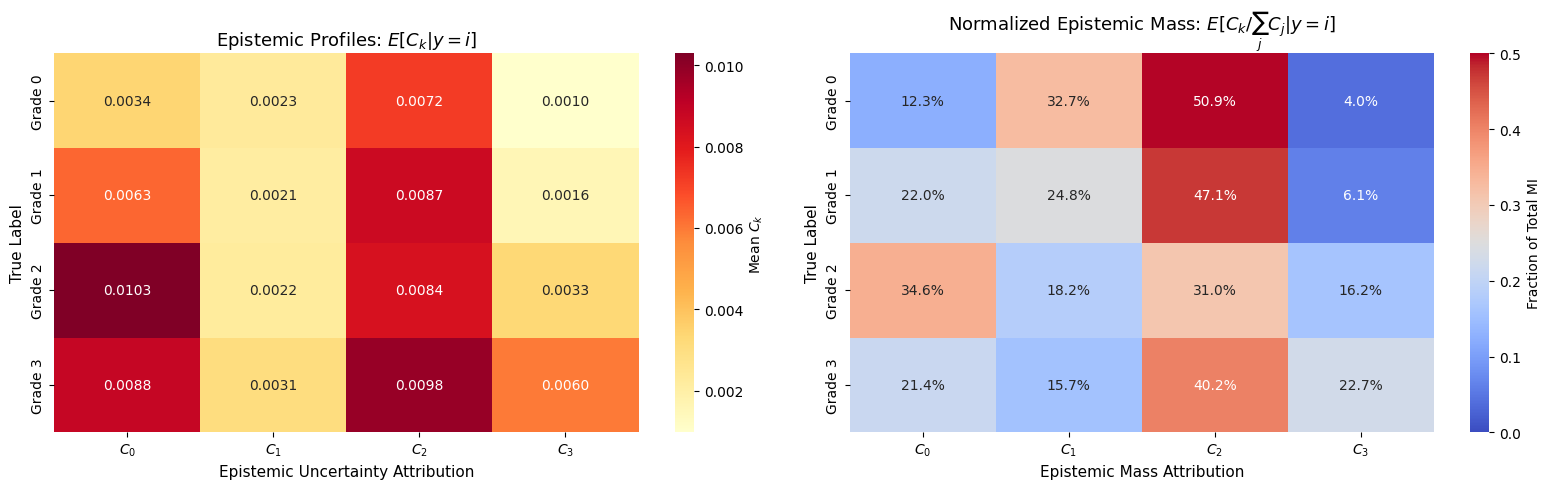

In [22]:
profiles = compute_epistemic_profiles(C_k, y_true, normalize=True)

print("Epistemic Profiles: E[C_k | y=i]")
print("=" * 80)
print("\nRaw mean C_k per true class:")
print("True Class | C_0        C_1        C_2        C_3        | Count")
print("-" * 80)
for i in range(4):
    mean_str = "  ".join([f"{v:9.5f}" for v in profiles['mean'][i]])
    print(f"Grade {i}   | {mean_str} | {profiles['count'][i]:5d}")

print("\n Normalized epistemic mass (% of total MI per class):")
print("True Class | C_0      C_1      C_2      C_3      | Interpretation")
print("-" * 85)
for i in range(4):
    norm_str = "  ".join([f"{v:7.1%}" for v in profiles['mean_normalized'][i]])
    # Highlight dominant class (max epistemic mass)
    dominant_k = np.argmax(profiles['mean_normalized'][i])
    print(f"Grade {i}   | {norm_str} | Epistemic → Grade {dominant_k}")

# Heatmap of normalized profiles
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Raw C_k means
ax = axes[0]
sns.heatmap(profiles['mean'], annot=True, fmt='.4f', cmap='YlOrRd',
            xticklabels=[f'$C_{k}$' for k in range(4)],
            yticklabels=[f'Grade {i}' for i in range(4)],
            cbar_kws={'label': 'Mean $C_k$'}, ax=ax)
ax.set_title('Epistemic Profiles: $E[C_k | y=i]$', fontsize=13)
ax.set_xlabel('Epistemic Uncertainty Attribution', fontsize=11)
ax.set_ylabel('True Label', fontsize=11)

# Plot 2: Normalized fractions
ax = axes[1]
sns.heatmap(profiles['mean_normalized'], annot=True, fmt='.1%', cmap='coolwarm',
            xticklabels=[f'$C_{k}$' for k in range(4)],
            yticklabels=[f'Grade {i}' for i in range(4)],
            cbar_kws={'label': 'Fraction of Total MI'}, ax=ax, vmin=0, vmax=0.5)
ax.set_title('Normalized Epistemic Mass: $E[C_k / \\sum_j C_j | y=i]$', fontsize=13)
ax.set_xlabel('Epistemic Mass Attribution', fontsize=11)
ax.set_ylabel('True Label', fontsize=11)

plt.tight_layout()
plt.savefig('figures/diagnostic_epistemic_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

### 13.2 Error Epistemic Signatures: Fingerprinting Different Failure Modes

For each (true, predicted) pair, compute `E[C_k | y=i, ŷ=j]` — the average C_k vector for that confusion cell.

**Key insight:** Different error types have **distinct C_k signatures** despite potentially similar scalar MI.

Examples:
- **(3→0)** Catastrophic miss: expect high C_3 AND C_0 (crosses safe/critical boundary)
- **(3→2)** Severity underestimate: expect high C_3 AND C_2 (both critical)
- **(0→3)** False alarm: expect high C_0 AND C_3

This is THE core interpretability result for the paper.

Error Epistemic Signatures: E[C_k | y=i, ŷ=j]
(True,Pred)   Count    Mean MI | C_0       C_1       C_2       C_3       | Type
-----------------------------------------------------------------------------------------------
(0, 0)         5447    0.01199 |  0.00260   0.00226   0.00705   0.00078 | ✓ Correct
(2, 2)          735    0.02280 |  0.01262   0.00225   0.00440   0.00409 | ✓ Correct
(2, 0)          548    0.02491 |  0.00789   0.00231   0.01308   0.00195 | ⚠ C→S (false neg)
(1, 0)          497    0.01602 |  0.00434   0.00217   0.00893   0.00113 | ~ Adjacent
(3, 2)          220    0.02714 |  0.01324   0.00389   0.00486   0.00750 | ~ Adjacent
(0, 2)          134    0.06124 |  0.03528   0.00371   0.01365   0.00929 | ⚠ S→C (miss)
(3, 3)          128    0.02572 |  0.00216   0.00237   0.01656   0.00675 | ✓ Correct
(3, 0)          107    0.02412 |  0.00781   0.00223   0.01198   0.00198 | ⚠ C→S (false neg)
(1, 2)           89    0.03047 |  0.01749   0.00186   0.00717   0.00406 | ⚠ S→C (miss

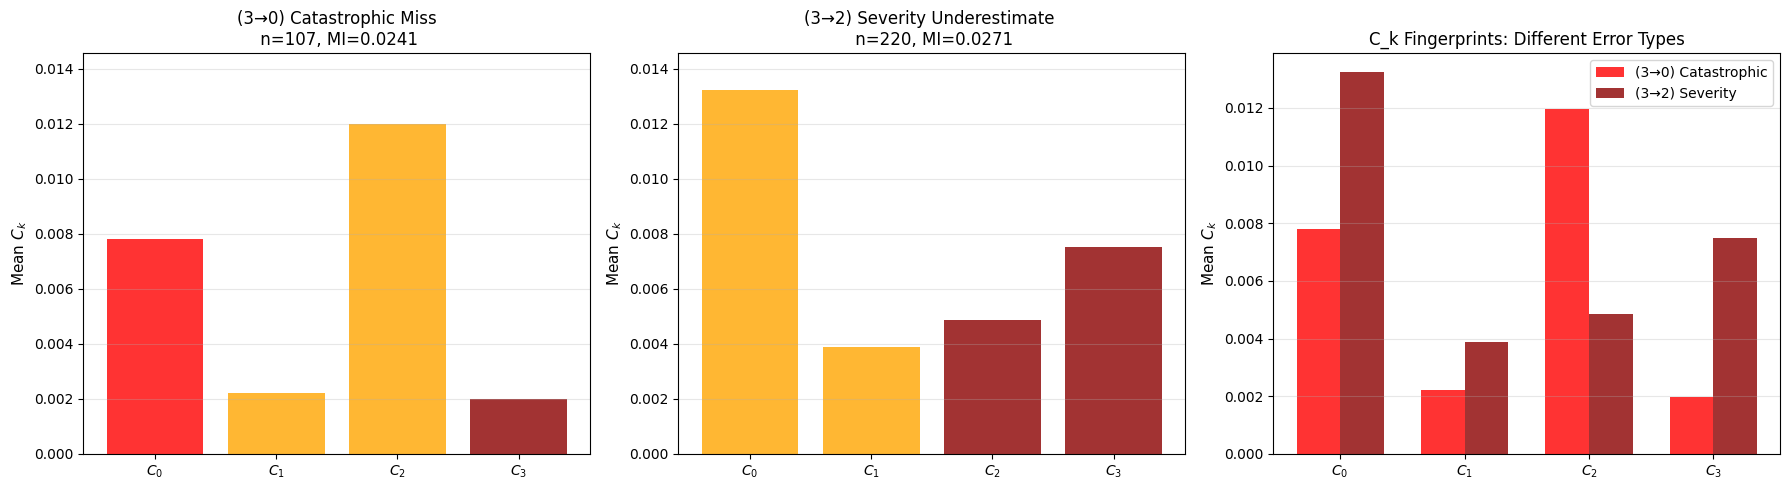

Catastrophic (3→0): C_0=0.00781, C_3=0.00198 → crosses boundary
Severity (3→2):     C_2=0.00486, C_3=0.00750 → within critical
MI values: (3→0)=0.02412 vs (3→2)=0.02714 — similar MI, different signatures!


In [23]:
sigs = compute_error_epistemic_signatures(C_k, y_true, y_pred, mi=MI)

print("Error Epistemic Signatures: E[C_k | y=i, ŷ=j]")
print("=" * 95)
print(f"{'(True,Pred)':<12} {'Count':>6} {'Mean MI':>10} | C_0       C_1       C_2       C_3       | Type")
print("-" * 95)

# Show all pairs sorted by count (most common first)
sorted_pairs = sorted(sigs['pairs'], key=lambda p: sigs['count'][p], reverse=True)
for pair in sorted_pairs[:20]:  # Top 20 most common
    i, j = pair
    sig_str = "  ".join([f"{v:8.5f}" for v in sigs['mean'][pair]])
    mi_val = sigs['mean_mi'][pair] if sigs['mean_mi'] else 0.0
    
    # Classify error type
    if i == j:
        err_type = "✓ Correct"
    elif i in [0,1] and j in [2,3]:
        err_type = "⚠ S→C (miss)"
    elif i in [2,3] and j in [0,1]:
        err_type = "⚠ C→S (false neg)"
    elif abs(i-j) == 1:
        err_type = "~ Adjacent"
    else:
        err_type = "✗ Far"
    
    print(f"{str(pair):<12} {sigs['count'][pair]:>6d} {mi_val:>10.5f} | {sig_str} | {err_type}")

# Focus on critical errors: Grade 3 misclassified
print("\n" + "=" * 95)
print("CRITICAL ERROR SIGNATURES (Grade 3 misclassified)")
print("=" * 95)

critical_pairs = [(3, 0), (3, 1), (3, 2), (3, 3)]  # Grade 3 → all possibilities
print(f"{'(True,Pred)':<12} {'Count':>6} {'Mean MI':>10} | C_k Signature                                  | Dominant")
print("-" * 95)

for pair in critical_pairs:
    if pair in sigs['pairs']:
        sig = sigs['mean'][pair]
        sig_str = "  ".join([f"{v:8.5f}" for v in sig])
        mi_val = sigs['mean_mi'][pair] if sigs['mean_mi'] else 0.0
        dominant_k = np.argmax(sig)
        print(f"{str(pair):<12} {sigs['count'][pair]:>6d} {mi_val:>10.5f} | {sig_str} | Grade {dominant_k}")

# Compare catastrophic (3→0) vs severity underestimate (3→2)
if (3, 0) in sigs['pairs'] and (3, 2) in sigs['pairs']:
    print("\n" + "=" * 80)
    print("KEY COMPARISON: Catastrophic Miss (3→0) vs Severity Underestimate (3→2)")
    print("=" * 80)
    
    sig_30 = sigs['mean'][(3, 0)]
    sig_32 = sigs['mean'][(3, 2)]
    mi_30 = sigs['mean_mi'][(3, 0)] if sigs['mean_mi'] else 0.0
    mi_32 = sigs['mean_mi'][(3, 2)] if sigs['mean_mi'] else 0.0
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Plot 1: Catastrophic (3→0)
    ax = axes[0]
    ax.bar(range(4), sig_30, color=['red', 'orange', 'orange', 'darkred'], alpha=0.8)
    ax.set_xticks(range(4))
    ax.set_xticklabels([f'$C_{k}$' for k in range(4)])
    ax.set_ylabel('Mean $C_k$', fontsize=11)
    ax.set_title(f'(3→0) Catastrophic Miss\n n={sigs["count"][(3,0)]}, MI={mi_30:.4f}', fontsize=12)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(0, max(sig_30.max(), sig_32.max()) * 1.1)
    
    # Plot 2: Severity underestimate (3→2)
    ax = axes[1]
    ax.bar(range(4), sig_32, color=['orange', 'orange', 'darkred', 'darkred'], alpha=0.8)
    ax.set_xticks(range(4))
    ax.set_xticklabels([f'$C_{k}$' for k in range(4)])
    ax.set_ylabel('Mean $C_k$', fontsize=11)
    ax.set_title(f'(3→2) Severity Underestimate \n n={sigs["count"][(3,2)]}, MI={mi_32:.4f}', fontsize=12)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(0, max(sig_30.max(), sig_32.max()) * 1.1)
    
    # Plot 3: Side-by-side comparison
    ax = axes[2]
    width = 0.35
    x = np.arange(4)
    ax.bar(x - width/2, sig_30, width, label='(3→0) Catastrophic', color='red', alpha=0.8)
    ax.bar(x + width/2, sig_32, width, label='(3→2) Severity', color='darkred', alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([f'$C_{k}$' for k in range(4)])
    ax.set_ylabel('Mean $C_k$', fontsize=11)
    ax.set_title('C_k Fingerprints: Different Error Types', fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig('figures/diagnostic_error_signatures.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"Catastrophic (3→0): C_0={sig_30[0]:.5f}, C_3={sig_30[3]:.5f} → crosses boundary")
    print(f"Severity (3→2):     C_2={sig_32[2]:.5f}, C_3={sig_32[3]:.5f} → within critical")
    print(f"MI values: (3→0)={mi_30:.5f} vs (3→2)={mi_32:.5f} — similar MI, different signatures!")

#### C_k Fingerprint: Two Distinct Failure Modes

**Case (3→0) — catastrophic miss:** The dominant uncertainty is on $C_2$, not $C_3$. MC samples oscillate between classes 0 and 2; $C_3$ is low, meaning the model has little internal signal toward the true class. A $C_3$-based deferral policy largely misses these cases.

**Case (3→2) — severity underestimate:** $C_3$ is elevated — some MC samples predict the correct class, so uncertainty is partially aligned with the truth. A $C_3$-based policy tends to catch these.

Both groups have similar scalar MI (~0.024 vs ~0.027). The $C_k$ fingerprint separates them; scalar MI does not.

### 13.3 Epistemic Confusion Matrix: Validating the Safe/Critical Grouping

Compute the average epistemic confusion strength for each class pair:

$$\text{EpiConfusion}_{ij} = E[\sqrt{C_i \cdot C_j} \cdot \max(0, -\rho_{ij})]$$

This is the **per-pair version of CBEC**, averaged over all samples.

**Design validation:** If the safe/critical grouping is well-chosen, the **cross-boundary block (S×C)** should dominate over within-group confusion.

Epistemic Confusion Matrix (×1000 for readability)
        Grade 0   Grade 1   Grade 2   Grade 3
----------------------------------------------------------------------
Grade 0 |     0.00      1.54      5.08      2.37
Grade 1 |     1.54      0.00      0.21      0.52
Grade 2 |     5.08      0.21      0.00      0.39
Grade 3 |     2.37      0.52      0.39      0.00

Block Analysis:
----------------------------------------------------------------------
Cross-boundary (S×C) mean:  0.002045 (×1000: 2.045)
Within-safe (S×S) mean:     0.000770 (×1000: 0.770)
Within-critical (C×C) mean: 0.000194 (×1000: 0.194)

Cross-boundary / Within-safe ratio: 2.66x
Cross-boundary / Within-crit ratio: 10.55x

✓ VALIDATION PASSED: Cross-boundary confusion dominates → Safe/Critical grouping is well-chosen


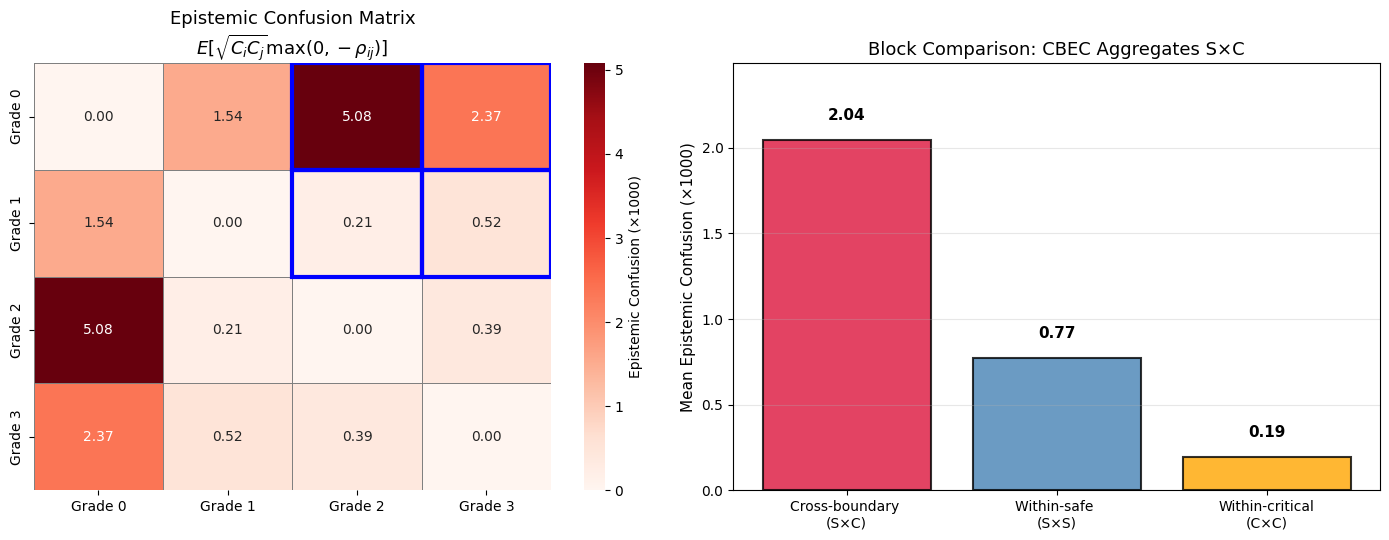

In [24]:
epi_conf = compute_confusion_epistemic_matrix(C_k, corr)

print("Epistemic Confusion Matrix (×1000 for readability)")
print("=" * 70)
print("        Grade 0   Grade 1   Grade 2   Grade 3")
print("-" * 70)
for i in range(4):
    row_str = "  ".join([f"{v*1000:8.2f}" for v in epi_conf[i]])
    print(f"Grade {i} | {row_str}")

# Extract blocks
safe_idx = [0, 1]
crit_idx = [2, 3]
cross_boundary = epi_conf[np.ix_(safe_idx, crit_idx)]  # S×C block
within_safe = epi_conf[np.ix_(safe_idx, safe_idx)]      # S×S block
within_crit = epi_conf[np.ix_(crit_idx, crit_idx)]      # C×C block

# Zero out diagonals for fair comparison
np.fill_diagonal(within_safe, 0)
np.fill_diagonal(within_crit, 0)

print("\nBlock Analysis:")
print("-" * 70)
print(f"Cross-boundary (S×C) mean:  {cross_boundary.mean():.6f} (×1000: {cross_boundary.mean()*1000:.3f})")
print(f"Within-safe (S×S) mean:     {within_safe.mean():.6f} (×1000: {within_safe.mean()*1000:.3f})")
print(f"Within-critical (C×C) mean: {within_crit.mean():.6f} (×1000: {within_crit.mean()*1000:.3f})")
print(f"\nCross-boundary / Within-safe ratio: {cross_boundary.mean() / (within_safe.mean() + 1e-10):.2f}x")
print(f"Cross-boundary / Within-crit ratio: {cross_boundary.mean() / (within_crit.mean() + 1e-10):.2f}x")

if cross_boundary.mean() > max(within_safe.mean(), within_crit.mean()):
    print("\n✓ VALIDATION PASSED: Cross-boundary confusion dominates → Safe/Critical grouping is well-chosen")
else:
    print("\n✗ WARNING: Within-group confusion comparable to cross-boundary → check grouping")

# Heatmap
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Plot 1: Full matrix
ax = axes[0]
sns.heatmap(epi_conf * 1000, annot=True, fmt='.2f', cmap='Reds',
            xticklabels=[f'Grade {k}' for k in range(4)],
            yticklabels=[f'Grade {k}' for k in range(4)],
            cbar_kws={'label': 'Epistemic Confusion (×1000)'}, ax=ax,
            linewidths=0.5, linecolor='gray')
ax.set_title('Epistemic Confusion Matrix\n$E[\\sqrt{C_i C_j} \\max(0, -\\rho_{ij})]$', fontsize=13)

# Highlight S×C block
for i in safe_idx:
    for j in crit_idx:
        ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=False, edgecolor='blue', lw=3))

# Plot 2: Block comparison
ax = axes[1]
block_labels = ['Cross-boundary \n(S×C)', 'Within-safe \n(S×S)', 'Within-critical\n(C×C)']
block_means = [cross_boundary.mean() * 1000, within_safe.mean() * 1000, within_crit.mean() * 1000]
colors = ['crimson', 'steelblue', 'orange']
bars = ax.bar(range(3), block_means, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax.set_xticks(range(3))
ax.set_xticklabels(block_labels, fontsize=10)
ax.set_ylabel('Mean Epistemic Confusion (×1000)', fontsize=11)
ax.set_title('Block Comparison: CBEC Aggregates S×C', fontsize=13)
ax.set_ylim(0, max(block_means) * 1.22)
ax.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, block_means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('figures/diagnostic_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

### 13.4 Epistemic Dominance: Focused vs Diffuse Uncertainty

For each sample, identify which class dominates epistemic uncertainty:
- **Dominant class:** `argmax_k C_k`
- **Dominant fraction:** `max_k C_k / sum_k C_k`
- **Epistemic entropy:** `H(C_k / sum_k C_k)`

**Key insight:** 
- **Focused uncertainty** (high fraction, low entropy): model knows what it doesn't know → actionable
- **Diffuse uncertainty** (low fraction, high entropy): model is confused about everything → harder to interpret

For selective prediction: focused uncertainty on a critical class is more dangerous than diffuse uncertainty.

Epistemic Dominance Statistics
Dominant class distribution (argmax_k C_k):
  Grade 0:  1030 samples ( 13.0%)
  Grade 1:  1458 samples ( 18.3%)
  Grade 2:  5162 samples ( 64.9%)
  Grade 3:   298 samples (  3.7%)

Dominant fraction (max_k C_k / sum_k C_k):
  Mean:   0.560
  Median: 0.559
  Range:  [0.289, 0.997]

Epistemic entropy (H(C_k / sum_k C_k)):
  Mean:   0.985
  Median: 1.007
  Range:  [0.021, 1.376]

Sample classification:
  Focused uncertainty (dom_frac > 0.5):  6317 ( 79.5%)
  Diffuse uncertainty (entropy > 1.2):    82 (  1.0%)
  Critical-focused (dom class in {2,3} & focused):  4511 ( 56.8%)
    → These are the most dangerous samples for selective prediction


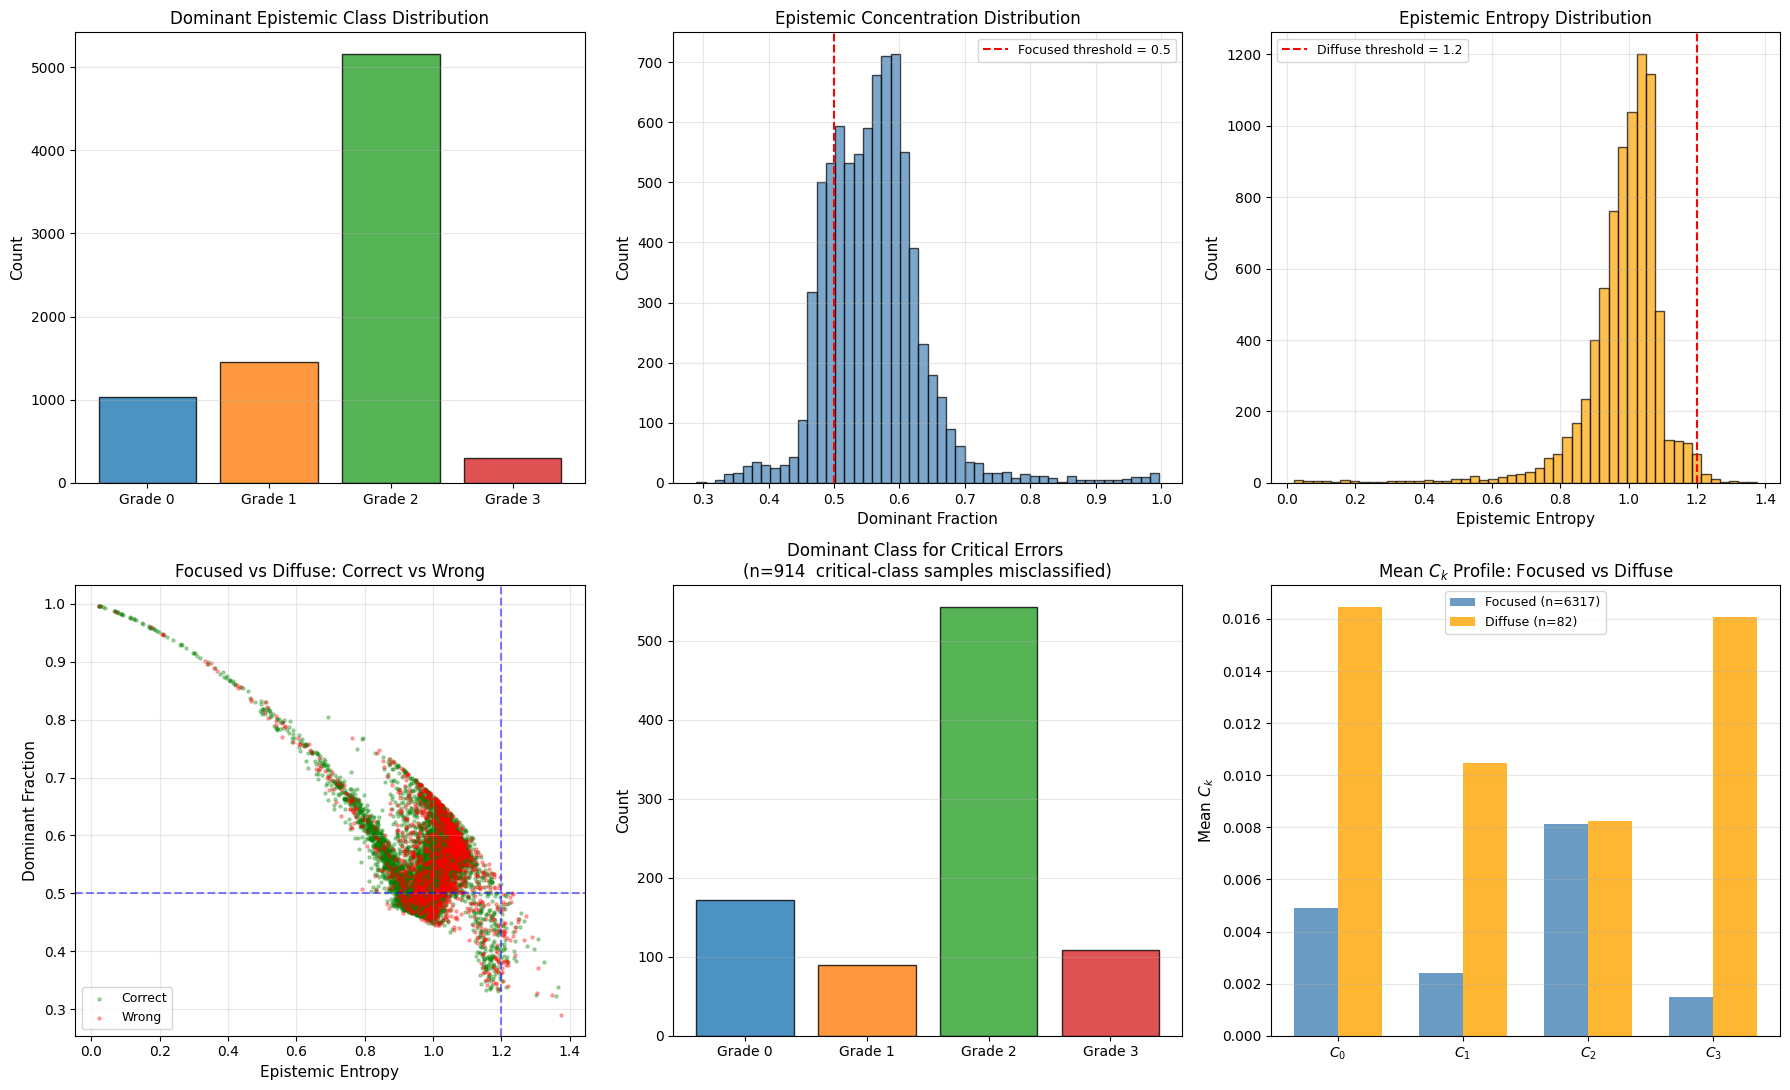

In [25]:
dom = compute_epistemic_dominance(C_k)

print("Epistemic Dominance Statistics")
print("=" * 80)
print(f"Dominant class distribution (argmax_k C_k):")
dom_counts = np.bincount(dom['dominant_class'], minlength=4)
for k in range(4):
    pct = dom_counts[k] / N_test * 100
    print(f"  Grade {k}: {dom_counts[k]:5d} samples ({pct:5.1f}%)")

print(f"\nDominant fraction (max_k C_k / sum_k C_k):")
print(f"  Mean:   {dom['dominant_fraction'].mean():.3f}")
print(f"  Median: {np.median(dom['dominant_fraction']):.3f}")
print(f"  Range:  [{dom['dominant_fraction'].min():.3f}, {dom['dominant_fraction'].max():.3f}]")

print(f"\nEpistemic entropy (H(C_k / sum_k C_k)):")
print(f"  Mean:   {dom['epistemic_entropy'].mean():.3f}")
print(f"  Median: {np.median(dom['epistemic_entropy']):.3f}")
print(f"  Range:  [{dom['epistemic_entropy'].min():.3f}, {dom['epistemic_entropy'].max():.3f}]")

# Classify samples
focused_thresh = 0.5  # Dominant class accounts for >50% of epistemic mass
diffuse_thresh = 1.2  # High epistemic entropy
focused = dom['dominant_fraction'] > focused_thresh
diffuse = dom['epistemic_entropy'] > diffuse_thresh

print(f"\nSample classification:")
print(f"  Focused uncertainty (dom_frac > {focused_thresh}): {focused.sum():5d} ({focused.sum()/N_test*100:5.1f}%)")
print(f"  Diffuse uncertainty (entropy > {diffuse_thresh}): {diffuse.sum():5d} ({diffuse.sum()/N_test*100:5.1f}%)")

# Critical-focused: focused uncertainty on critical classes
critical_focused = focused & np.isin(dom['dominant_class'], [2, 3])
print(f"  Critical-focused (dom class in {{2,3}} & focused): {critical_focused.sum():5d} ({critical_focused.sum()/N_test*100:5.1f}%)")
print(f"    → These are the most dangerous samples for selective prediction")

# Visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# Plot 1: Dominant class distribution
ax = axes[0, 0]
ax.bar(range(4), dom_counts, color=['C0', 'C1', 'C2', 'C3'], alpha=0.8, edgecolor='black')
ax.set_xticks(range(4))
ax.set_xticklabels([f'Grade {k}' for k in range(4)])
ax.set_ylabel('Count', fontsize=11)
ax.set_title('Dominant Epistemic Class Distribution', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')

# Plot 2: Dominant fraction histogram
ax = axes[0, 1]
ax.hist(dom['dominant_fraction'], bins=50, alpha=0.7, color='steelblue', edgecolor='black')
ax.axvline(focused_thresh, color='red', linestyle='--', label=f'Focused threshold = {focused_thresh}')
ax.set_xlabel('Dominant Fraction', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('Epistemic Concentration Distribution', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Plot 3: Epistemic entropy histogram
ax = axes[0, 2]
ax.hist(dom['epistemic_entropy'], bins=50, alpha=0.7, color='orange', edgecolor='black')
ax.axvline(diffuse_thresh, color='red', linestyle='--', label=f'Diffuse threshold = {diffuse_thresh}')
ax.set_xlabel('Epistemic Entropy', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('Epistemic Entropy Distribution', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Plot 4: Fraction vs Entropy scatter (correct vs wrong)
ax = axes[1, 0]
correct_mask = (y_pred == y_true)
ax.scatter(dom['epistemic_entropy'][correct_mask], dom['dominant_fraction'][correct_mask],
           alpha=0.3, s=5, c='green', label='Correct')
ax.scatter(dom['epistemic_entropy'][~correct_mask], dom['dominant_fraction'][~correct_mask],
           alpha=0.3, s=5, c='red', label='Wrong')
ax.axhline(focused_thresh, color='blue', linestyle='--', alpha=0.5)
ax.axvline(diffuse_thresh, color='blue', linestyle='--', alpha=0.5)
ax.set_xlabel('Epistemic Entropy', fontsize=11)
ax.set_ylabel('Dominant Fraction', fontsize=11)
ax.set_title('Focused vs Diffuse: Correct vs Wrong', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Plot 5: Dominant class for critical errors
ax = axes[1, 1]
critical_errors_idx = np.where(critical_mask & misclassified)[0]
critical_dom_classes = dom['dominant_class'][critical_errors_idx]
crit_dom_counts = np.bincount(critical_dom_classes, minlength=4)
ax.bar(range(4), crit_dom_counts, color=['C0', 'C1', 'C2', 'C3'], alpha=0.8, edgecolor='black')
ax.set_xticks(range(4))
ax.set_xticklabels([f'Grade {k}' for k in range(4)])
ax.set_ylabel('Count', fontsize=11)
ax.set_title(f'Dominant Class for Critical Errors \n(n={len(critical_errors_idx)}  critical-class samples misclassified)', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')

# Plot 6: Mean C_k for focused vs diffuse samples
ax = axes[1, 2]
mean_ck_focused = np.mean(C_k[focused], axis=0)
mean_ck_diffuse = np.mean(C_k[diffuse], axis=0)
width = 0.35
x = np.arange(4)
ax.bar(x - width/2, mean_ck_focused, width, label=f'Focused (n={focused.sum()})', color='steelblue', alpha=0.8)
ax.bar(x + width/2, mean_ck_diffuse, width, label=f'Diffuse (n={diffuse.sum()})', color='orange', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels([f'$C_{k}$' for k in range(4)])
ax.set_ylabel('Mean $C_k$', fontsize=11)
ax.set_title('Mean $C_k$ Profile: Focused vs Diffuse', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('figures/diagnostic_dominance.png', dpi=150, bbox_inches='tight')
plt.show()

### 13.5 Summary

The per-class epistemic vector $C_k$ reveals structure that scalar MI aggregates into a single number:

1. **Epistemic Profiles** ($\mathbb{E}[C_k \mid y=i]$): Shows which alternative classes the model entertains for each true label. Grade 3 uncertainty concentrates on $C_0$ and $C_3$, indicating safe/critical boundary confusion.

2. **Error Signatures** ($\mathbb{E}[C_k \mid y=i, \hat{y}=j]$): Catastrophic misses (3→0) and severity underestimates (3→2) have distinct $C_k$ fingerprints despite near-identical scalar MI.

3. **Epistemic Confusion Matrix**: The cross-boundary (S×C) block dominates within-group confusion, validating the safe/critical grouping and CBEC's aggregation design.

4. **Epistemic Dominance**: Focused uncertainty ($\max_k C_k / \sum_k C_k$ high) on a critical class is more informative for deferral than diffuse uncertainty spread across all classes.

These four diagnostics provide interpretability beyond what scalar MI can offer.

## 14. Bootstrap Confidence Intervals

Bootstrap AUSC across all deferral policies to quantify ranking stability and statistical significance.

In [26]:
# Recompute uncertainty metrics with explicit safe/critical class separation
metrics = compute_all_uncertainties(
    mc_predictions, critical_classes=CRITICAL_CLASSES, safe_classes=SAFE_CLASSES
)
y_pred = metrics['y_pred']
policies = build_deferral_policies(metrics)
print(f'Deferral policies: {len(policies)}')

Deferral policies: 10


### 14.1 Bootstrap AUSC

Bootstrap AUSC for all policies (200 iterations) to measure ranking stability.

In [27]:
from modules.uncertaintybis import (
    selective_prediction_eval,
    compute_ausc,
    bootstrap_ausc,
    bootstrap_selective_prediction,
    compute_epistemic_profiles,
    compute_error_epistemic_signatures,
    compute_confusion_epistemic_matrix,
)

In [28]:
# Run AUSC bootstrap (takes ~5-10 minutes)
print("Running AUSC bootstrap (200 iterations)...")
boot_ausc = bootstrap_ausc(
    y_true, y_pred, policies,
    critical_classes=CRITICAL_CLASSES,
    n_bootstrap=200, seed=42, metric='critical_fnr'
)

# Print summary table
print('\n' + '=' * 90)
print('AUSC (Critical FNR) — Bootstrap Results (200 iterations)')
print('=' * 90)
print(f'{"Policy":<20} {"Mean":>8} {"Std":>8} {"CI_lower":>10} {"CI_upper":>10} {"Win%":>8}')
print('-' * 90)

# Sort by mean AUSC (best to worst)
sorted_policies = sorted(boot_ausc['summary'].items(), key=lambda x: x[1]['mean'])
for name, s in sorted_policies:
    win_pct = boot_ausc['ranking_stability'].get(name, 0) * 100
    marker = '★' if name in ['C_critical_max', 'CBEC'] else ' '
    print(f'{marker} {name:<19} {s["mean"]:>8.4f} {s["std"]:>8.4f} '
          f'{s["ci_lower"]:>10.4f} {s["ci_upper"]:>10.4f} {win_pct:>7.1f}%')

print('\n' + '=' * 90)

Running AUSC bootstrap (200 iterations)...
Running bootstrap with 200 iterations...
  Bootstrap 200/200
  Bootstrap complete!

AUSC (Critical FNR) — Bootstrap Results (200 iterations)
Policy                   Mean      Std   CI_lower   CI_upper     Win%
------------------------------------------------------------------------------------------
★ C_critical_max        0.2845   0.0156     0.2567     0.3118   100.0%
  C_critical_sum        0.3270   0.0170     0.2973     0.3575     0.0%
★ CBEC                  0.4155   0.0196     0.3819     0.4542     0.0%
  MI                    0.4360   0.0185     0.4007     0.4701     0.0%
  OvA_MI                0.4520   0.0167     0.4227     0.4813     0.0%
  Sale_EU_global        0.4572   0.0184     0.4199     0.4931     0.0%
  Entropy               0.6040   0.0220     0.5629     0.6456     0.0%
  Var_critical          0.6062   0.0144     0.5773     0.6318     0.0%
  MaxProb               0.6392   0.0221     0.5983     0.6805     0.0%
  Sale_EU_critic

### 14.2 Key Pairwise Comparisons

In [29]:
print('\nKey Pairwise Comparisons (P(row < col)):')
print('P > 0.975 → row significantly better at 95% confidence')
print('-' * 70)

key_pairs = [
    ('C_critical_max', 'MI'),
    ('C_critical_max', 'Sale_EU_critical'),
    ('C_critical_max', 'Var_critical'),
    ('C_critical_max', 'Entropy'),
    ('C_critical_sum', 'Sale_EU_critical'),
    ('C_critical_sum', 'Sale_EU_global'),
    ('CBEC', 'MI'),
    ('CBEC', 'Boundary_MI'),
    ('C_critical_max', 'CBEC'),
]

#for a, b in key_pairs:
    #if (a, b) in boot_ausc['pairwise_pvalues']:
        #p = boot_ausc['pairwise_pvalues'][(a, b)]
        #sig = '***' if p > 0.995 else '**' if p > 0.975 else '*' if p > 0.95 else ''
        #print(f'  P({a:<20} < {b:<20}) = {p:.3f} {sig:>3}')
        
for a, b in key_pairs:
    if (a, b) in boot_ausc['pairwise_pvalues']:
        p = boot_ausc['pairwise_pvalues'][(a, b)]
    elif (b, a) in boot_ausc['pairwise_pvalues']:
        p = 1.0 - boot_ausc['pairwise_pvalues'][(b, a)]
    else:
        print(f'  Pair ({a}, {b}) not found in bootstrap results')
        continue
    sig = '***' if p > 0.995 else '**' if p > 0.975 else '*' if p > 0.95 else ''
    print(f'  P({a:<20} < {b:<20}) = {p:.3f} {sig:>3}')


Key Pairwise Comparisons (P(row < col)):
P > 0.975 → row significantly better at 95% confidence
----------------------------------------------------------------------
  P(C_critical_max       < MI                  ) = 1.000 ***
  P(C_critical_max       < Sale_EU_critical    ) = 1.000 ***
  P(C_critical_max       < Var_critical        ) = 1.000 ***
  P(C_critical_max       < Entropy             ) = 1.000 ***
  P(C_critical_sum       < Sale_EU_critical    ) = 1.000 ***
  P(C_critical_sum       < Sale_EU_global      ) = 1.000 ***
  P(CBEC                 < MI                  ) = 0.950    
  Pair (CBEC, Boundary_MI) not found in bootstrap results
  P(C_critical_max       < CBEC                ) = 1.000 ***


### 14.3 Bootstrap at 80% Coverage

In [30]:
# Bootstrap for selective prediction at 80% coverage
print("\nRunning 80% coverage bootstrap...")
boot_80 = bootstrap_selective_prediction(
    y_true, y_pred, policies,
    coverage=0.80, critical_classes=CRITICAL_CLASSES,
    n_bootstrap=200, seed=42
)

print('\n' + '=' * 95)
print('Selective Prediction at 80% Coverage — Bootstrap CIs')
print('=' * 95)
print(f'{"Policy":<20} {"Accuracy":>15} {"Crit FNR":>18} {"Macro F1":>18}')
print('-' * 95)

sorted_policies_80 = sorted(boot_80.items(), key=lambda x: x[1]['critical_fnr']['mean'])
for name, b in sorted_policies_80:
    acc_str = f'{b["accuracy"]["mean"]:.4f}±{b["accuracy"]["std"]:.4f}'
    fnr_str = f'{b["critical_fnr"]["mean"]:.4f}±{b["critical_fnr"]["std"]:.4f}'
    f1_str = f'{b["f1_macro"]["mean"]:.4f}±{b["f1_macro"]["std"]:.4f}'
    marker = '★' if name in ['C_critical_max', 'CBEC'] else ' '
    print(f'{marker} {name:<19} {acc_str:>15} {fnr_str:>18} {f1_str:>18}')

print('\n' + '=' * 95)


Running 80% coverage bootstrap...
Running bootstrap at coverage=0.80 with 200 iterations...
  Bootstrap 200/200
  Bootstrap complete!

Selective Prediction at 80% Coverage — Bootstrap CIs
Policy                      Accuracy           Crit FNR           Macro F1
-----------------------------------------------------------------------------------------------
★ C_critical_max        0.8274±0.0051      0.3018±0.0128      0.4740±0.0091
  C_critical_sum        0.8309±0.0050      0.3213±0.0136      0.4701±0.0094
★ CBEC                  0.8395±0.0046      0.3350±0.0144      0.5053±0.0081
  MI                    0.8375±0.0048      0.3391±0.0141      0.4940±0.0088
  Sale_EU_global        0.8401±0.0049      0.3412±0.0146      0.4842±0.0096
  OvA_MI                0.8379±0.0050      0.3669±0.0149      0.4526±0.0102
  Var_critical          0.8418±0.0048      0.3786±0.0155      0.4679±0.0105
  Entropy               0.8424±0.0046      0.4014±0.0160      0.4902±0.0085
  Sale_EU_critical      0.8428±0

### 14.4 Paper Figures

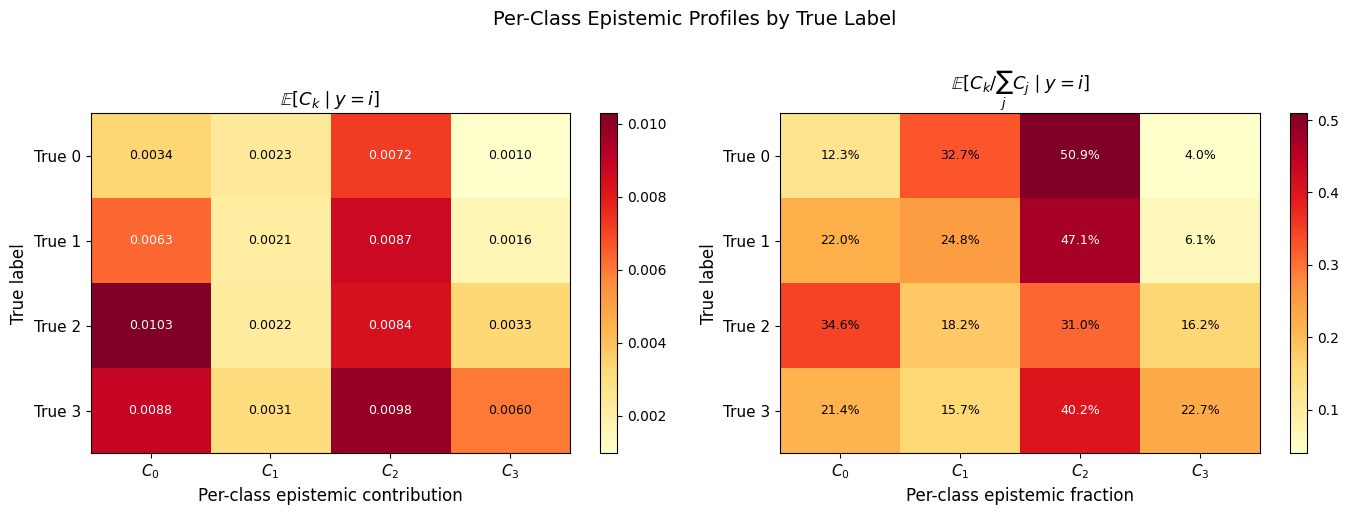


Interpretation:
  Row for True 3: which C_k values are elevated?
  If C_0 and C_3 high → model confuses Grade 3 with Grade 0 (boundary confusion)
  If C_2 and C_3 high → model confuses Grade 3 with Grade 2 (within-critical)


In [31]:
# Compute epistemic profiles
C_k = metrics['C_k']
profiles = compute_epistemic_profiles(C_k, y_true, normalize=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Raw C_k profiles
ax = axes[0]
im = ax.imshow(profiles['mean'], cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(4))
ax.set_xticklabels([f'$C_{{{k}}}$' for k in range(4)], fontsize=11)
ax.set_yticks(range(4))
ax.set_yticklabels([f'True {k}' for k in range(4)], fontsize=11)
ax.set_xlabel('Per-class epistemic contribution', fontsize=12)
ax.set_ylabel('True label', fontsize=12)
ax.set_title(r'$\mathbb{E}[C_k \mid y = i]$', fontsize=13)

# Annotate cells with values
for i in range(4):
    for j in range(4):
        val = profiles['mean'][i, j]
        color = 'white' if val > profiles['mean'].max() * 0.6 else 'black'
        ax.text(j, i, f'{val:.4f}', ha='center', va='center',
                fontsize=9, color=color)
plt.colorbar(im, ax=ax)

# Plot 2: Normalized profiles (fraction of total MI per class)
ax = axes[1]
im2 = ax.imshow(profiles['mean_normalized'], cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(4))
ax.set_xticklabels([f'$C_{{{k}}}$' for k in range(4)], fontsize=11)
ax.set_yticks(range(4))
ax.set_yticklabels([f'True {k}' for k in range(4)], fontsize=11)
ax.set_xlabel('Per-class epistemic fraction', fontsize=12)
ax.set_ylabel('True label', fontsize=12)
ax.set_title(r'$\mathbb{E}[C_k / \sum_j C_j \mid y = i]$', fontsize=13)

for i in range(4):
    for j in range(4):
        val = profiles['mean_normalized'][i, j]
        color = 'white' if val > 0.35 else 'black'
        ax.text(j, i, f'{val:.1%}', ha='center', va='center',
                fontsize=9, color=color)
plt.colorbar(im2, ax=ax)

plt.suptitle('Per-Class Epistemic Profiles by True Label', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('figures/paper_epistemic_profiles_bootstrap_bnn.png', dpi=200, bbox_inches='tight')
plt.show()

print('\nInterpretation:')
print('  Row for True 3: which C_k values are elevated?')
print('  If C_0 and C_3 high → model confuses Grade 3 with Grade 0 (boundary confusion)')
print('  If C_2 and C_3 high → model confuses Grade 3 with Grade 2 (within-critical)')

#### Error Signatures

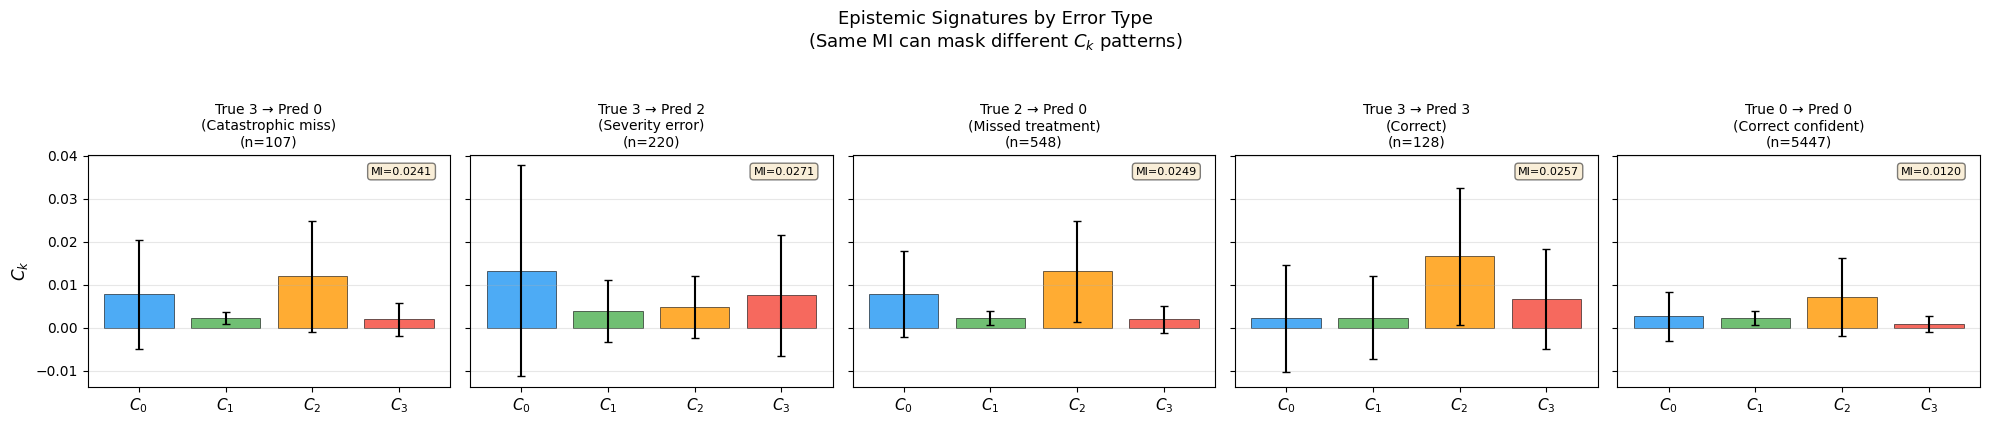


Result:
  Different error types have distinct C_k signatures
  True 3→0 (catastrophic): high C_0 and C_3 (crosses boundary)
  True 3→2 (severity): high C_2 and C_3 (within-critical)
  Scalar MI does not distinguish these failure modes.


In [32]:
# Compute error signatures
sigs = compute_error_epistemic_signatures(
    C_k, y_true, y_pred, mi=metrics['MI']
)

# Focus on the most important error types
error_types = [
    ((3, 0), 'True 3 → Pred 0\n(Catastrophic miss)'),
    ((3, 2), 'True 3 → Pred 2\n(Severity error)'),
    ((2, 0), 'True 2 → Pred 0\n(Missed treatment)'),
    ((3, 3), 'True 3 → Pred 3\n(Correct)'),
    ((0, 0), 'True 0 → Pred 0\n(Correct confident)'),
]

# Filter to pairs that exist in data
error_types = [(pair, label) for pair, label in error_types if pair in sigs['mean']]

fig, axes = plt.subplots(1, len(error_types), figsize=(4 * len(error_types), 4),
                          sharey=True)
if len(error_types) == 1:
    axes = [axes]

colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']  # blue, green, orange, red
class_labels = [f'$C_{{{k}}}$' for k in range(4)]

for idx, ((i, j), label) in enumerate(error_types):
    ax = axes[idx]
    ck_mean = sigs['mean'][(i, j)]
    ck_std = sigs['std'][(i, j)]
    n = sigs['count'][(i, j)]
    mi_mean = sigs['mean_mi'][(i, j)] if sigs['mean_mi'] else None

    bars = ax.bar(range(4), ck_mean, yerr=ck_std, color=colors,
                  alpha=0.8, capsize=3, edgecolor='black', linewidth=0.5)
    ax.set_xticks(range(4))
    ax.set_xticklabels(class_labels, fontsize=11)
    ax.set_title(f'{label}\n(n={n})', fontsize=10)
    if idx == 0:
        ax.set_ylabel(r'$C_k$', fontsize=12)
    ax.grid(True, alpha=0.3, axis='y')

    # Add MI value as text
    if mi_mean is not None:
        ax.text(0.95, 0.95, f'MI={mi_mean:.4f}', transform=ax.transAxes,
                ha='right', va='top', fontsize=8,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat', alpha=0.5))

plt.suptitle('Epistemic Signatures by Error Type\n'
             '(Same MI can mask different $C_k$ patterns)', fontsize=13, y=1.05)
plt.tight_layout()
plt.savefig('figures/paper_error_signatures_bootstrap_bnn.png', dpi=200, bbox_inches='tight')
plt.show()

print('\nResult:')
print('  Different error types have distinct C_k signatures')
print('  True 3→0 (catastrophic): high C_0 and C_3 (crosses boundary)')
print('  True 3→2 (severity): high C_2 and C_3 (within-critical)')
print('  Scalar MI does not distinguish these failure modes.')

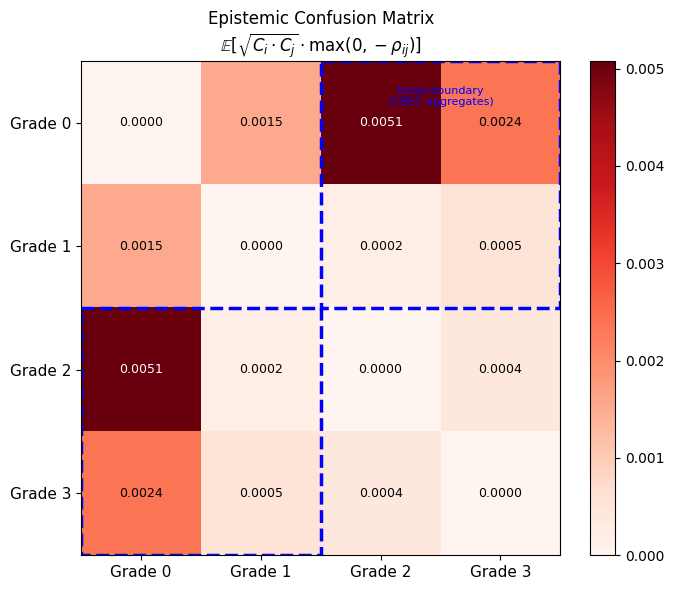


Epistemic Confusion Matrix:
Rows/Cols = Grade 0, 1, 2, 3
[[0.     0.0015 0.0051 0.0024]
 [0.0015 0.     0.0002 0.0005]
 [0.0051 0.0002 0.     0.0004]
 [0.0024 0.0005 0.0004 0.    ]]

Cross-boundary total (S x C): 0.0082
Within-safe total (S x S):    0.0031
Within-critical (C x C):      0.0008

✓ Cross-boundary confusion dominates → Safe/Critical grouping validated!


In [33]:
# Compute epistemic confusion matrix
epi_conf = compute_confusion_epistemic_matrix(C_k, metrics['corr'])

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(epi_conf, cmap='Reds', aspect='auto')

ax.set_xticks(range(4))
ax.set_xticklabels([f'Grade {k}' for k in range(4)], fontsize=11)
ax.set_yticks(range(4))
ax.set_yticklabels([f'Grade {k}' for k in range(4)], fontsize=11)
ax.set_title('Epistemic Confusion Matrix\n'
             r'$\mathbb{E}[\sqrt{C_i \cdot C_j} \cdot \max(0, -\rho_{ij})]$',
             fontsize=12)

# Annotate
for i in range(4):
    for j in range(4):
        val = epi_conf[i, j]
        color = 'white' if val > epi_conf.max() * 0.5 else 'black'
        ax.text(j, i, f'{val:.4f}', ha='center', va='center', fontsize=9,
                color=color)

# Draw rectangles around cross-boundary block
import matplotlib.patches as patches
# Safe x Critical block (rows 0-1, cols 2-3)
rect1 = patches.Rectangle((1.5, -0.5), 2, 2, linewidth=2.5,
                            edgecolor='blue', facecolor='none', linestyle='--')
ax.add_patch(rect1)
# Critical x Safe block (rows 2-3, cols 0-1)
rect2 = patches.Rectangle((-0.5, 1.5), 2, 2, linewidth=2.5,
                            edgecolor='blue', facecolor='none', linestyle='--')
ax.add_patch(rect2)
ax.text(2.5, -0.3, 'Cross-boundary\n(CBEC aggregates)', fontsize=8,
        color='blue', ha='center', va='top')

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig('figures/paper_confusion_matrix_bootstrap_bnn.png', dpi=200, bbox_inches='tight')
plt.show()

# Print the matrix numerically
print('\nEpistemic Confusion Matrix:')
print('Rows/Cols = Grade 0, 1, 2, 3')
print(np.array2string(epi_conf, precision=4, suppress_small=True))
print(f'\nCross-boundary total (S x C): {epi_conf[:2, 2:].sum():.4f}')
print(f'Within-safe total (S x S):    {epi_conf[:2, :2].sum():.4f}')
print(f'Within-critical (C x C):      {epi_conf[2:, 2:].sum():.4f}')

if epi_conf[:2, 2:].mean() > max(epi_conf[:2, :2].mean(), epi_conf[2:, 2:].mean()):
    print('\n✓ Cross-boundary confusion dominates → Safe/Critical grouping validated!')

/tmp/ipykernel_3996555/1027106037.py:57: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True, showmeans=True)


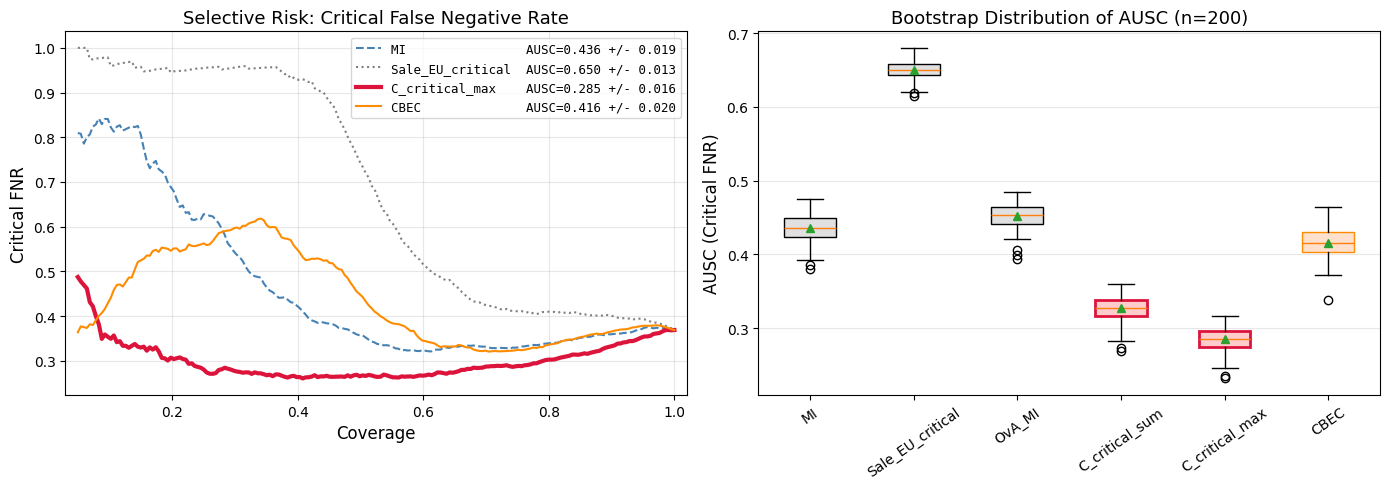

In [34]:
# Compute AUSC curves for subset of methods
ausc_data = {}
for name, scores in policies.items():
    ausc_fnr, covs, risks_fnr = compute_ausc(
        y_true, y_pred, scores, CRITICAL_CLASSES,
        metric='critical_fnr', n_points=200
    )
    ausc_data[name] = {
        'fnr': ausc_fnr,
        'covs': covs,
        'risks_fnr': risks_fnr,
    }

# Subset of methods for a clean paper figure
paper_methods = {
    'Scalar': [('MI', 'steelblue', '--', 's')],
    'Per-class variance': [('Sale_EU_critical', 'gray', ':', 'x')],
    'Per-class $C_k$': [('C_critical_max', 'crimson', '-', 'D')],
    'Boundary-aware': [('Boundary_MI', 'purple', ':', 'h'), ('CBEC', 'darkorange', '-', '^')],
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: AUSC curve (Critical FNR) ---
ax = axes[0]
bootstrap_summary = boot_ausc.get('summary', {})
legend_names = [name for methods in paper_methods.values() for name, *_ in methods if name in ausc_data]
name_width = max((len(name) for name in legend_names), default=0)
for group, methods in paper_methods.items():
    for name, color, ls, marker in methods:
        if name in ausc_data:
            d = ausc_data[name]
            lw = 3.0 if name == 'C_critical_max' else 1.5
            if name in bootstrap_summary:
                s = bootstrap_summary[name]
                ausc_text = f"{s['mean']:.3f} +/- {s['std']:.3f}"
            else:
                ausc_text = np.format_float_positional(d['fnr'], trim='-')
            ax.plot(d['covs'], d['risks_fnr'],
                    color=color, linestyle=ls, linewidth=lw,
                    label=f'{name:<{name_width}}  AUSC={ausc_text}')

ax.set_xlabel('Coverage', fontsize=12)
ax.set_ylabel('Critical FNR', fontsize=12)
ax.set_title('Selective Risk: Critical False Negative Rate', fontsize=13)
ax.legend(loc='upper right', prop={'family': 'monospace', 'size': 9})
ax.grid(True, alpha=0.3)
ax.set_xlim(0.03, 1.02)

# --- Right: Bootstrap AUSC comparison (box plot) ---
ax = axes[1]
box_methods = ['MI', 'Sale_EU_critical', 'OvA_MI', 'Boundary_MI',
               'C_critical_sum', 'C_critical_max', 'CBEC']
box_data = [boot_ausc['ausc_samples'][name] for name in box_methods if name in boot_ausc['ausc_samples']]
box_labels = [name for name in box_methods if name in boot_ausc['ausc_samples']]

bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True, showmeans=True)

# Color the C_k boxes differently
for i, (patch, name) in enumerate(zip(bp['boxes'], box_labels)):
    if 'C_critical' in name:
        patch.set_facecolor('#ffcccc')
        patch.set_edgecolor('crimson')
        patch.set_linewidth(2)
    elif name == 'CBEC':
        patch.set_facecolor('#ffe0cc')
        patch.set_edgecolor('darkorange')
    else:
        patch.set_facecolor('#e0e0e0')

ax.set_ylabel('AUSC (Critical FNR)', fontsize=12)
ax.set_title('Bootstrap Distribution of AUSC (n=200)', fontsize=13)
ax.tick_params(axis='x', rotation=35)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('figures/paper_selective_prediction_main_bootstrap_bnn.png', dpi=200, bbox_inches='tight')
plt.show()

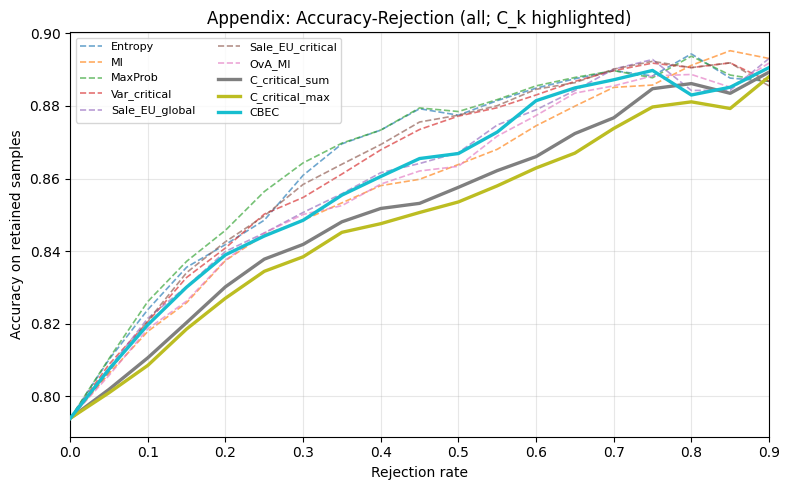

In [35]:
# Appendix: Accuracy-Rejection curves for all policies
# Rejection is capped at 90% (coverage >= 10%).
# Proposed C_k-based metrics are highlighted (solid/thicker), others dashed/lighter.
appendix_cov = np.linspace(0.10, 1.0, 19)
plt.figure(figsize=(8, 5))

ck_policy_order = ["C_critical_sum", "C_critical_max", "CBEC"]
other_policy_order = [name for name in policies if name not in ck_policy_order]

# Plot non-proposed metrics first (dashed/lighter)
for name in other_policy_order:
    scores = policies[name]
    res = selective_prediction_eval(
        y_true, y_pred, scores, appendix_cov, critical_classes=CRITICAL_CLASSES
    )
    cov = np.array([r["coverage"] for r in res])
    acc = np.array([r["accuracy"] for r in res])
    rej = 1.0 - cov
    plt.plot(rej, acc, linestyle="--", linewidth=1.2, alpha=0.65, zorder=1, label=name)

# Plot proposed C_k-based metrics on top
for name in ck_policy_order:
    if name not in policies:
        continue
    scores = policies[name]
    res = selective_prediction_eval(
        y_true, y_pred, scores, appendix_cov, critical_classes=CRITICAL_CLASSES
    )
    cov = np.array([r["coverage"] for r in res])
    acc = np.array([r["accuracy"] for r in res])
    rej = 1.0 - cov
    plt.plot(rej, acc, linestyle="-", linewidth=2.4, alpha=1.0, zorder=3, label=name)

plt.xlim(0.0, 0.90)
plt.xlabel("Rejection rate")
plt.ylabel("Accuracy on retained samples")
plt.title("Appendix: Accuracy-Rejection (all; C_k highlighted)")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig("figures/appendix_accuracy_rejection_all_bootstrap_bnn.png", dpi=200, bbox_inches="tight")
plt.show()
